# Titanic — Complete Supervised ML Pipeline
### From Raw Data → Production-Grade Models

| Phase | Topic | Concepts Covered |
|-------|-------|-----------------|
| 1 | Data Understanding | EDA, describe(), MCAR/MAR/MNAR, distributions |
| 2 | Feature Engineering | Title extraction, FamilyBin, HasCabin, log1p, imputation |
| 3 | Baseline Modeling | Logistic Regression, coefficients, multicollinearity |
| 4 | Algorithm Comparison | LR, DT, RF, SVM, KNN, XGBoost — 5-fold CV |
| 5 | Learning Curves | Bias-variance diagnosis, gap analysis |
| 6 | Hyperparameter Tuning | GridSearchCV coarse→fine, RandomizedSearchCV |
| 7 | Production Pipelines | sklearn Pipeline, custom Transformers, .pkl export |
| 8 | Model Explainability | SHAP values, force plots, feature importance |
| 9 | Experiment Tracking | MLflow runs, metrics, artifact logging |

> **Dataset**: Titanic passenger survival (binary classification)  
> **Target**: `Survived` (0 = died, 1 = survived)  
> **Evaluation**: Accuracy, AUC-ROC, F1, Precision, Recall

In [1]:
!pip install --upgrade shap


In [2]:
import shap

In [3]:
!pip install numpy pandas scikit-learn matplotlib seaborn shap mlflow jupyter ipykernel

In [4]:
!pip install xgboost

In [5]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from scipy import stats
from pathlib import Path


In [6]:
from sklearn.model_selection import (train_test_split,cross_val_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler,LabelEncoder,MinMaxScaler

# ML — Core
from sklearn.model_selection import (train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV, RandomizedSearchCV, learning_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# ML — Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# ML — Metrics
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay)
# ML — Metrics
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay)

# Explainability & Tracking
import shap
import mlflow
import mlflow.sklearn
import joblib as joblib

In [ ]:
DATA_PATH   = Path('../practice/datasets/kaggle/titanic/train.csv')
MODEL_DIR   = Path('../practice/models/titanic'); MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR  = Path('../practice/outputs/titanic'); OUTPUT_DIR.mkdir(exist_ok=True)

Step 1: Before building or touching the model understand the data in depth
    What is the data
    what is wrong with the data or missing
    what are the pattern(s)existed in the data 

In [8]:
# load the titanic dataset
titanic_df=pd.read_csv(DATA_PATH)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Following will give single shot of data types,non null counts, column wise percentage of null in the dataset,number of unique values, displaying sample element how the data looks like

In [10]:
info_df = pd.DataFrame({
    'dtype'   : titanic_df.dtypes,
    'non_null': titanic_df.count(),
    'null_pct': (titanic_df.isnull().mean()*100).round(1),
    'unique'  : titanic_df.nunique(),
    'sample'  : [titanic_df[c].dropna().iloc[0] if titanic_df[c].count()>0 else None for c in titanic_df.columns]
})
print(info_df.to_string())

               dtype  non_null  null_pct  unique                   sample
PassengerId    int64       891       0.0     891                        1
Survived       int64       891       0.0       2                        0
Pclass         int64       891       0.0       3                        3
Name          object       891       0.0     891  Braund, Mr. Owen Harris
Sex           object       891       0.0       2                     male
Age          float64       714      19.9      88                     22.0
SibSp          int64       891       0.0       7                        1
Parch          int64       891       0.0       7                        0
Ticket        object       891       0.0     681                A/5 21171
Fare         float64       891       0.0     248                     7.25
Cabin         object       204      77.1     147                      C85
Embarked      object       889       0.2       3                        S


In [11]:
stats=titanic_df.describe()

In [12]:
stats.loc['range']=stats.loc['max'] -stats.loc['min']
stats.loc['iqr']=stats.loc['75%'] -stats.loc['25%']
stats.loc['cv']=stats.loc['std']/stats.loc['mean']
stats.loc['skew_signal']=stats.loc['mean'] -stats.loc['50%'] # median
stats.loc['lower_bound']=stats.loc['25%']-(1.5 * stats.loc['iqr'])
stats.loc['upper_bound']=stats.loc['75%']+(1.5 * stats.loc['iqr'])
stats.loc['extreme_lower_bound']=stats.loc['25%']-(3 * stats.loc['iqr'])
stats.loc['extreme_upper_bound']=stats.loc['75%']+(3 * stats.loc['iqr'])

In [13]:
stats

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200
range,890.000000,1.000000,2.000000,79.580000,8.000000,6.000000,512.329200
iqr,445.000000,1.000000,1.000000,17.875000,1.000000,0.000000,23.089600



Note:
Lower bound=Q1−1.5×IQR
Upper bound=Q3+1.5×IQR
👉 Any value outside this range = potential anomaly.
            Q1−3×IQR,Q3+3×IQR
👉 These are strong anomalies / data errors
From describe():
mean
50% (median)
Rule:
mean ≈ median → symmetric distribution
mean >> median → right skew (possible high outliers)
mean << median → left skew (possible low outliers)
👉 Large difference = possible anomalies or skewed distribution

From describe():

mean.  
        Sum of all values ÷ number of values
        Mean=∑xi/n​​
median:

        Definition
                Middle value after sorting
        If even → average of two middle values
                [1, 2, 3, 100] → median = (2+3)/2 = 2.5
-------------------------------------------            
| Situation        | Mean       | Median  |
| ---------------- | ---------- | ------- |
| No outliers      | Similar    | Similar |
| Outliers present | Distorted  | Stable  |
| Skewed data      | Misleading | Better  |
-------------------------------------------

Variance.
    👉 Definition

            Average of squared distance from mean. σ2=1/n(​∑(xi​−μ)2)
    💡 Intuition
            “How far are values from the mean (on average)?”
            Small variance → data tightly packed
            Large variance → data spread out
       Why squared?
            To avoid negative distances
            Gives more weight to extreme values
Standard deviation:
        👉 Definition
                Square root of variance
                σ=sqrt(σ2)
    💡 Intuition
                “Typical distance from the mean”
                Same unit as data (unlike variance)

Variance vs Std Dev
-------------------------------------------------
  Metric   | Unit          | Interpretation      |
| -------- | ------------- | ------------------- |
| Variance | squared units | harder to interpret |
| Std Dev  | same as data  | easy, practical     |
--------------------------------------------------
👉 In ML:
    We mostly use standard deviation
You use them to:
    Detect outliers
    Normalize data (standardization)
    Understand distributions
    Feature scaling


In [14]:
stats

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200
range,890.000000,1.000000,2.000000,79.580000,8.000000,6.000000,512.329200
iqr,445.000000,1.000000,1.000000,17.875000,1.000000,0.000000,23.089600


## 📘 Theory: Reading df.describe()

> `df.describe()` gives 8 statistics for each numeric column.  
> Here is what each tells you:
>
> | Stat | Meaning | Red Flag |
> |------|---------|----------|
> | `count` | Non-null values | count < len(df) → missing data |
> | `mean` | Average | far from median → skewed/outliers |
> | `std` | Spread | large std → high variance feature |
> | `min` / `max` | Range | impossible values (age=-1, fare=0) |
> | `25%`/`75%` | IQR boundaries | IQR used for outlier detection |
> | `50%` | Median | mean≠median → non-normal distribution |

In [15]:
titanic_df['Name'].nunique()


891

Observation all names are unique names

In [16]:
num_cols=titanic_df.select_dtypes(include=np.number).columns.drop(['PassengerId','Survived'])
num_cols

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [17]:
desc=titanic_df[num_cols].describe(percentiles=[0.01,0.05,0.25,0.50,0.75,0.95,0.99]).T

desc['skew']=titanic_df[num_cols].skew().round(3)
desc['kurtosis']=titanic_df[num_cols].kurtosis().round(3)
desc['cv']=(titanic_df[num_cols].std()/titanic_df[num_cols].mean()).round(3)

In [18]:
print("Extended Numeric Summary:")
print(desc.round(2).to_string())
print()
print("Skew interpretation: |skew| < 0.5 = symmetric | 0.5–1 = moderate | >1 = high")

Extended Numeric Summary:
        count   mean    std   min   1%    5%    25%    50%   75%     95%     99%     max  skew  kurtosis    cv
Pclass  891.0   2.31   0.84  1.00  1.0  1.00   2.00   3.00   3.0    3.00    3.00    3.00 -0.63     -1.28  0.36
Age     714.0  29.70  14.53  0.42  1.0  4.00  20.12  28.00  38.0   56.00   65.87   80.00  0.39      0.18  0.49
SibSp   891.0   0.52   1.10  0.00  0.0  0.00   0.00   0.00   1.0    3.00    5.00    8.00  3.70     17.88  2.11
Parch   891.0   0.38   0.81  0.00  0.0  0.00   0.00   0.00   0.0    2.00    4.00    6.00  2.75      9.78  2.11
Fare    891.0  32.20  49.69  0.00  0.0  7.22   7.91  14.45  31.0  112.08  249.01  512.33  4.79     33.40  1.54

Skew interpretation: |skew| < 0.5 = symmetric | 0.5–1 = moderate | >1 = high


 ** Note: if names are uniques no need to check for duplicates and counts
 Basic column wise observations:
 
 PClass
 
 1. min =1, max=3 this is one of the basic observation reveals there are only 3 passenger classes
 2. Mean = 2.31, Median = 3 → Majority of passengers are in 3rd class.
 3. Skew = -0.63 (moderate left skew) → More passengers concentrated in higher class numbers (3rd class).
 4. Kurtosis = -1.28 → Flatter distribution (no extreme peaks).
 5. Very low variability (CV = 0.36) → Values tightly distributed between 1–3.
   Insight: Dataset is imbalanced toward lower socioeconomic class.
   


Age 

1. min=0.42 max=80.0 indicates onboarded passengers from months baby to 80 years old 
2. Skew = 0.39 (low) → Slight right skew.
3. 95% percentile = 56, 99% = ~66 → Few elderly outliers.
4. CV = 0.49 → Moderate variability.
Insights:

Most passengers are young adults (20–40 years).
Presence of infants (min ~0.4 years).
Missing values need treatment before modeling.

SibSp (Siblings/Spouses aboard)

1. Mean = 0.52, Median = 0 → Most passengers traveled alone.
2. Skew = 3.70 (highly right skewed).
3. Kurtosis = 17.88 → Extreme outliers present.
4. 95% = 3, Max = 8.

👉 Insights:

Majority have no siblings/spouses onboard.
Few passengers with large family sizes → strong outliers.

Parch (Parents/Children aboard)

Mean = 0.38, Median = 0 → Most passengers did not travel with parents/children.
Skew = 2.75 (high) → Strong right skew.
Kurtosis = 9.78 → Outliers exist.
Max = 6.

👉 Insights:

Similar to SibSp → family travel is rare.
Some extreme cases of large family groups.

Fare (Ticket Price)

Mean = 32.2, Median = 14.45 → Large difference → strong right skew.
Skew = 4.79 (extremely high).
Kurtosis = 33.40 → Very heavy tails (extreme outliers).
Range = 0 to 512.
95% = 112, 99% = 249 → Huge jump → confirms outliers.
CV = 1.54 → Very high variability.

👉 Insights:

Most passengers paid low fares, but a few paid very high prices.
Strong indicator of wealth disparity.
Requires log transformation or outlier handling.

1. UNIVARIATE ANALYSIS (Single Variable)
   ✅ Goal:

Understand distribution, skewness, spread

i). Numeric Features (Age, Fare, SibSp, Parch)
   Histogram + KDE (best for skewness)

In [19]:
# for col in titanic_df.select_dtypes(include=np.number).columns:
#         plt.figure(figsize=(6,4))
#         sb.histplot(titanic_df[col], kde=True)
#         plt.title(f'Distribution of {col}')
#         plt.show()

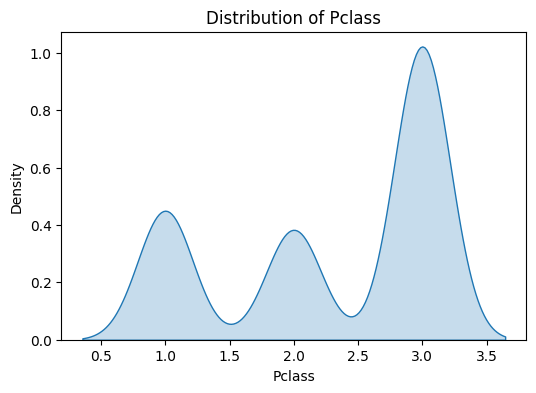

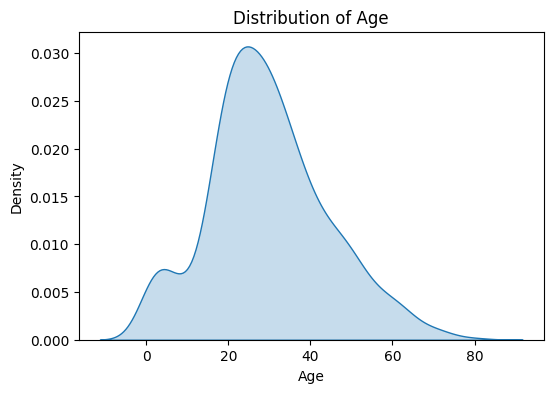

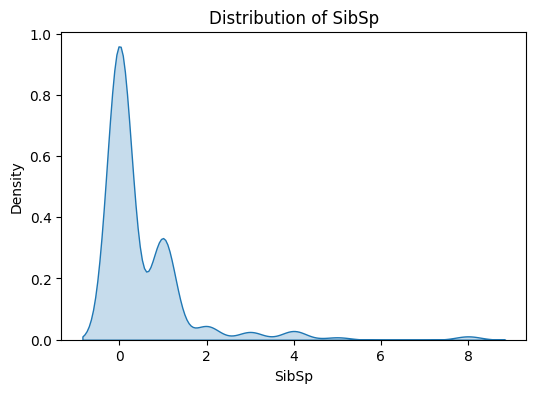

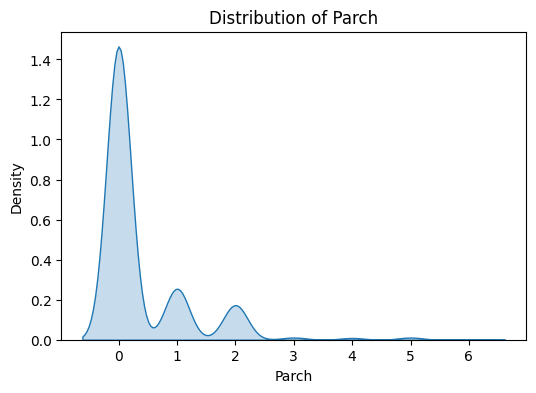

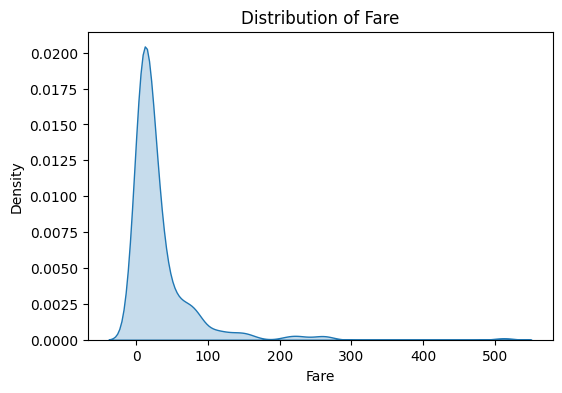

In [20]:
for col in titanic_df.select_dtypes(include=np.number).columns.drop(['PassengerId','Survived']):
        plt.figure(figsize=(6,4))
        sb.kdeplot(titanic_df,x=col,fill=True)
        plt.title(f'Distribution of {col}')
        plt.show()

Observation 

Fare → highly right skewed
Age → near symmetric
SibSp, Parch → zero-heavy + skewed

2 . Boxplot (Outliers detection)

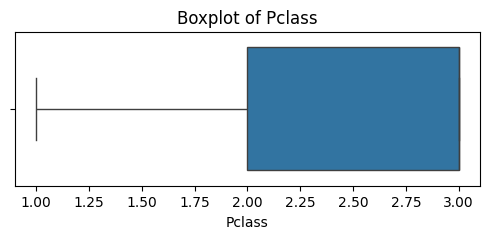

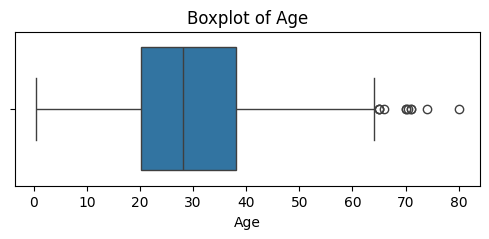

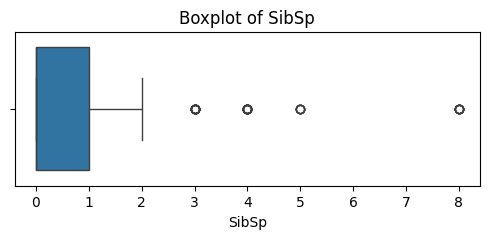

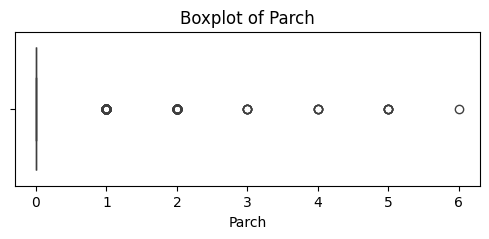

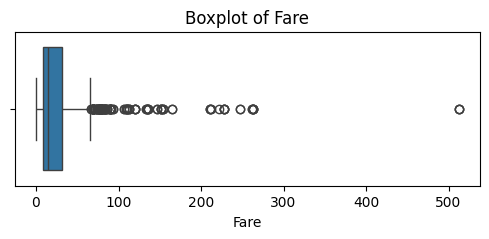

In [21]:
for col in titanic_df.select_dtypes(include=np.number).columns.drop(['PassengerId','Survived']):
    plt.figure(figsize=(6,2))
    sb.boxplot(x=titanic_df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Identifies:

Extreme values in Fare
Outliers in family size variables

3. Categorical Features (Pclass, Sex, Embarked)

In [22]:
for col in titanic_df.select_dtypes(include=['object', 'category']).columns:
    print(col)

Name
Sex
Ticket
Cabin
Embarked


In [23]:
titanic_df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


technically passenger class i.e 'Pclass' categorical data representation but data type in int64 or numerical (numpy stand point of view). name, ticket, title is not considering


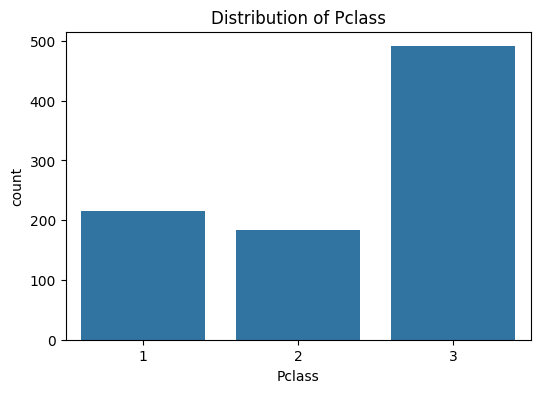

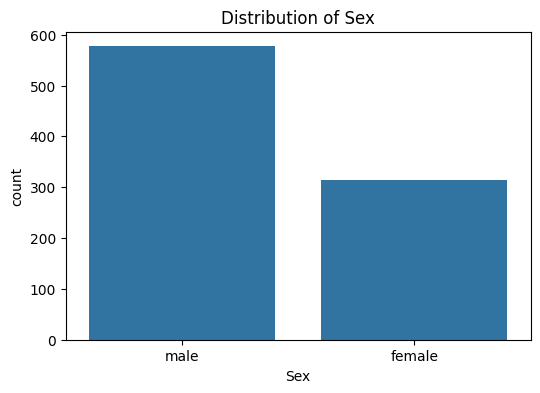

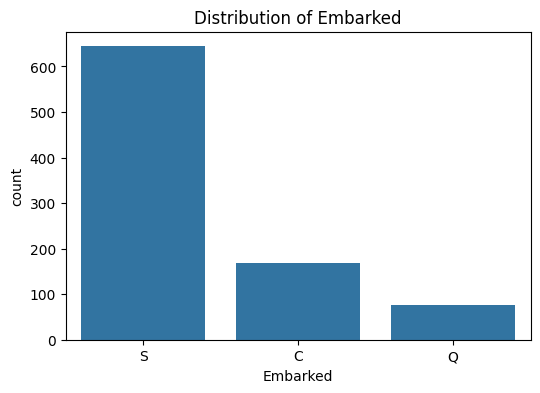

In [24]:
cat_cols = ['Pclass', 'Sex', 'Embarked']
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sb.countplot(x=col, data=titanic_df)
    plt.title(f'Distribution of {col}')
    plt.show()

Observations:

Pclass → mostly 3rd class

Sex → more males

Embarked → mostly from S

2. BIVARIATE ANALYSIS (Two Variables)
   
   ✅ Goal:

Understand relationships & impact on survival

A. Numeric vs Target (Survived)

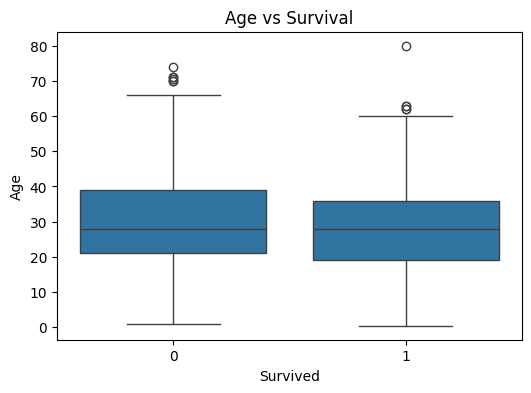

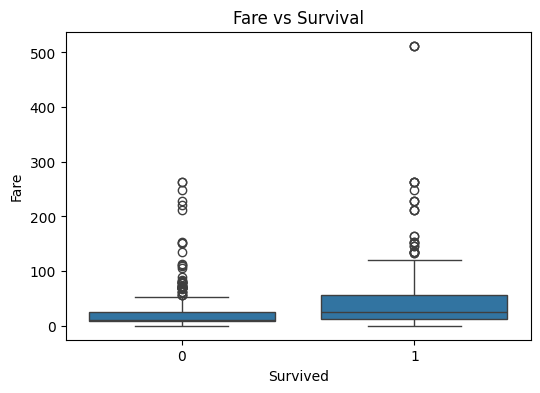

In [25]:
for col in ['Age', 'Fare']:
    plt.figure(figsize=(6,4))
    sb.boxplot(x='Survived', y=col, data=titanic_df)
    plt.title(f'{col} vs Survival')
    plt.show()

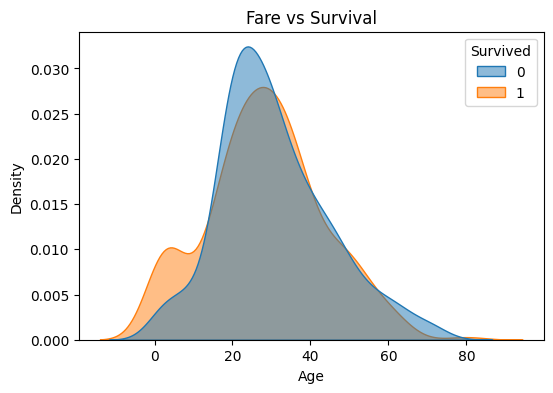

In [26]:

plt.figure(figsize=(6,4))
sb.kdeplot(data=titanic_df,x='Age',hue='Survived',fill=True,common_norm=False, alpha=0.5)
plt.title(f'{col} vs Survival')
plt.show()

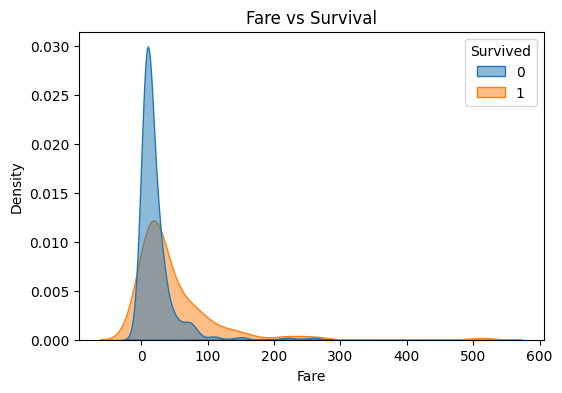

In [27]:
plt.figure(figsize=(6,4))
sb.kdeplot(data=titanic_df,x='Fare',hue='Survived',fill=True,common_norm=False, alpha=0.5)
plt.title(f'{col} vs Survival')
plt.show()

B. Categorical vs Target

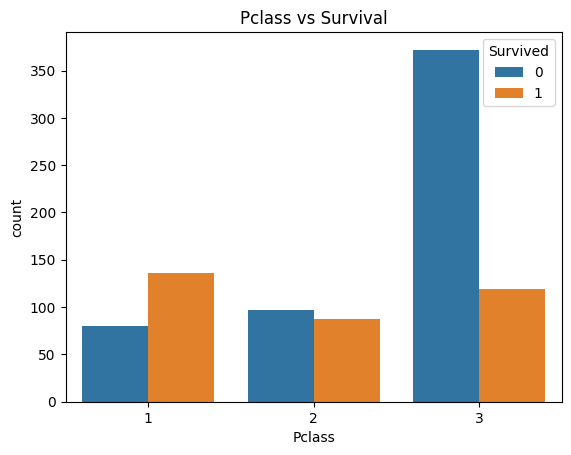

In [28]:
sb.countplot(x='Pclass', hue='Survived', data=titanic_df)
plt.title('Pclass vs Survival')
plt.show()

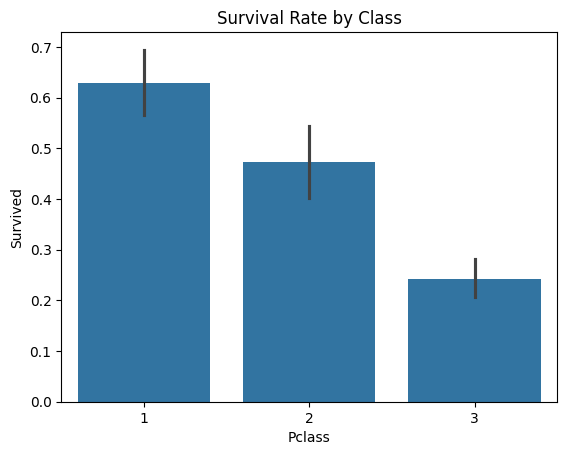

In [29]:
sb.barplot(x='Pclass', y='Survived', data=titanic_df)
plt.title('Survival Rate by Class')
plt.show()

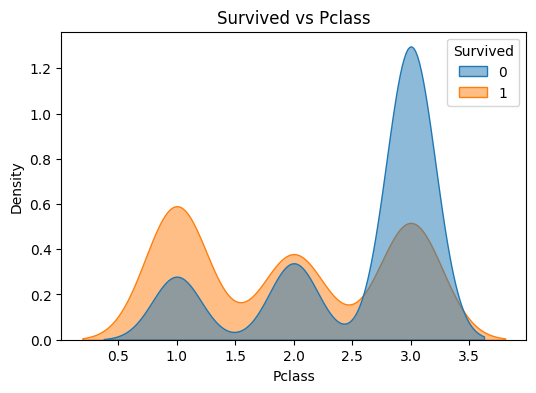

In [30]:
plt.figure(figsize=(6,4))
sb.kdeplot(data=titanic_df,x='Pclass',hue='Survived',fill=True,common_norm=False, alpha=0.5)
plt.title(f'Survived vs Pclass')
plt.show()

C. Numeric vs Numeric

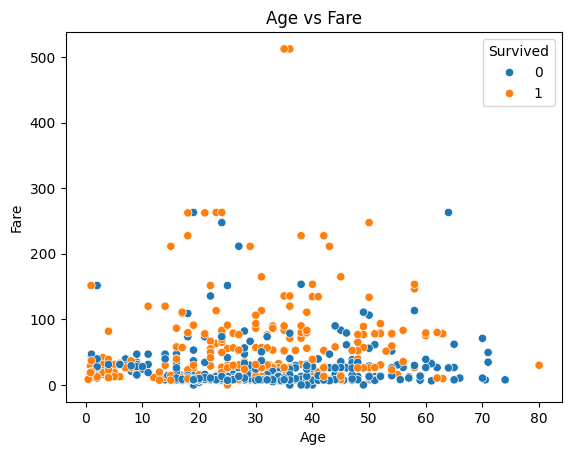

In [31]:
sb.scatterplot(x='Age', y='Fare', hue='Survived', data=titanic_df)
plt.title('Age vs Fare')
plt.show()

High fare passengers cluster → higher survival

3. MULTIVARIATE ANALYSIS (3+ Variables)

A. Pairplot (Quick overview)

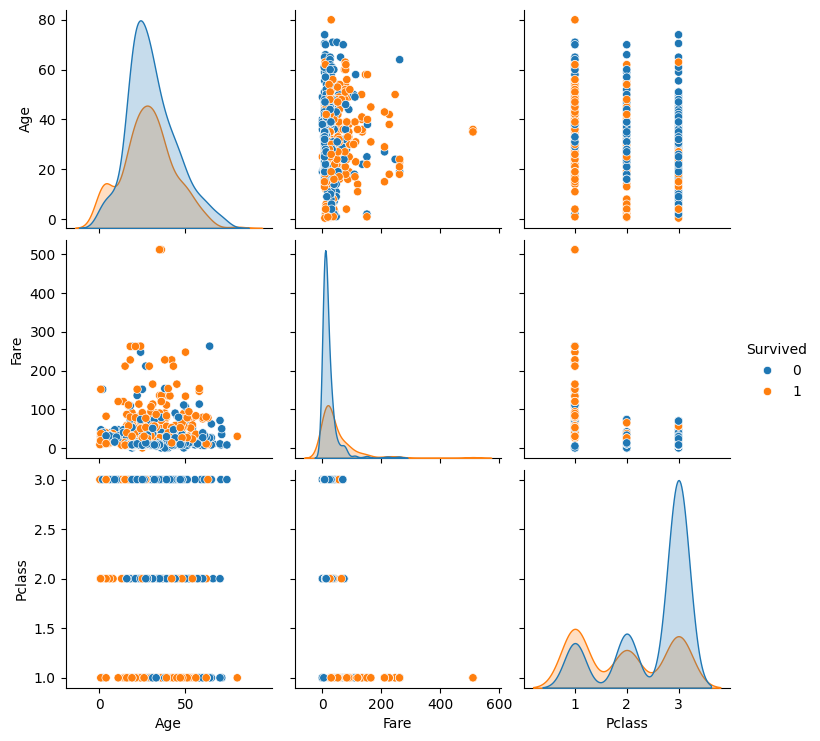

In [32]:
sb.pairplot(titanic_df[['Age','Fare','Pclass','Survived']], hue='Survived')
plt.show()

Shows combined relationships in one go

Great for spotting separability

B. Heatmap (Correlation)

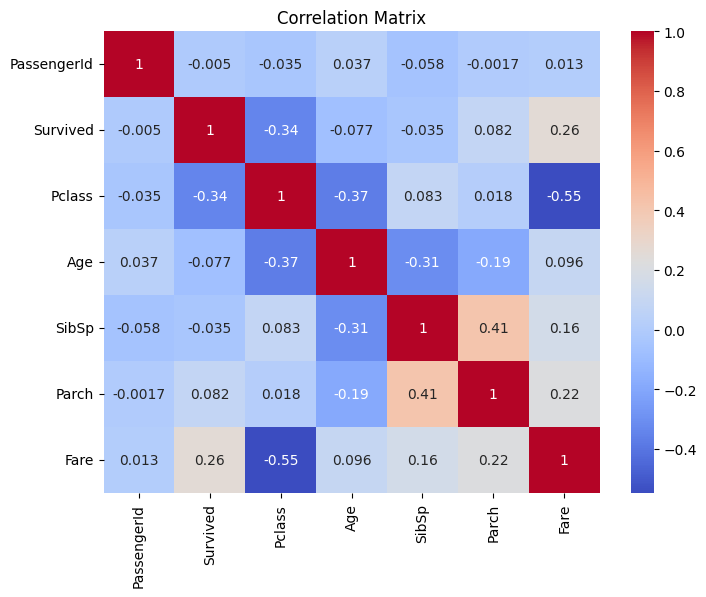

In [33]:
plt.figure(figsize=(8,6))
sb.heatmap(titanic_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Fare correlates with Pclass
Survived mildly correlated with:
Fare (+)
Pclass (-)

C. Survival by Multiple Features

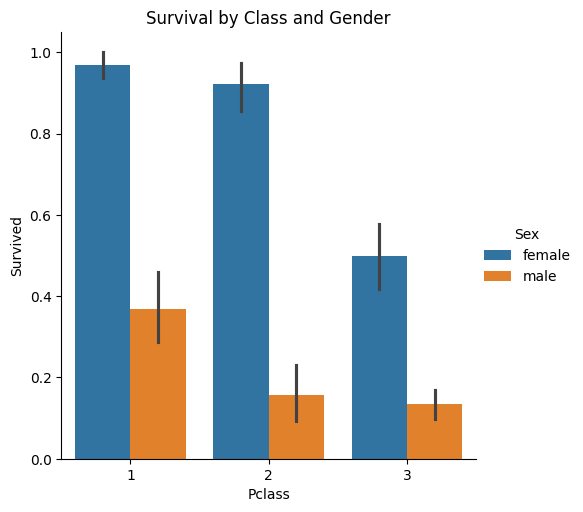

In [34]:
sb.catplot(x='Pclass', y='Survived', hue='Sex', kind='bar', data=titanic_df)
plt.title('Survival by Class and Gender')
plt.show()

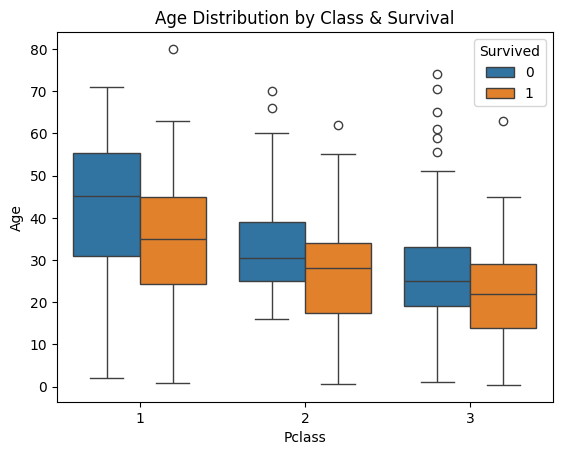

In [35]:
sb.boxplot(x='Pclass', y='Age', hue='Survived', data=titanic_df)
plt.title('Age Distribution by Class & Survival')
plt.show()

D. Facet Grid (Advanced)

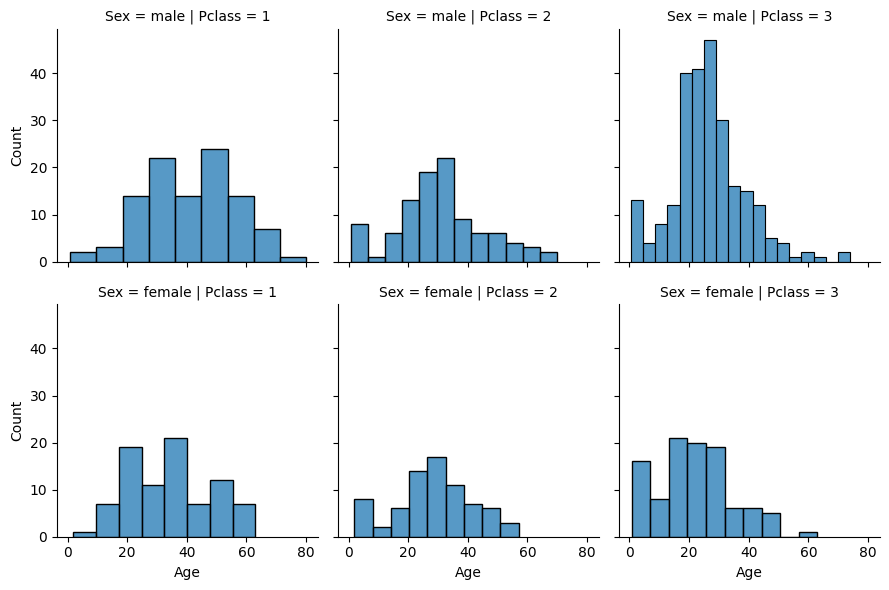

In [36]:
g = sb.FacetGrid(titanic_df, col='Pclass', row='Sex')
g.map(sb.histplot, 'Age')
plt.show()

## Missing Value Taxonomy (MCAR / MAR / MNAR)

> Understanding **WHY** data is missing determines HOW to handle it.
>
> | Type | Full Name | Meaning | Example | Treatment |
> |------|-----------|---------|---------|-----------|
> | **MCAR** | Missing Completely At Random | No pattern; random dropout | Sensor glitch | Mean/median imputation safe |
> | **MAR** | Missing At Random | Depends on *observed* variables | Age missing more for 3rd class | Group-based imputation |
> | **MNAR** | Missing Not At Random | Depends on the *missing value itself* | High earners skip income | Binary flag + impute |
>
> **Titanic-specific:**
> - `Age` → MAR (missing more in Pclass 3 → impute by Pclass+Sex group median)
> - `Cabin` → MNAR (only wealthy recorded cabin; absence carries signal → `HasCabin` flag)
> - `Embarked` → MCAR (2 random nulls → safe to impute with mode)

In [37]:
print("figuring out all the missing values")
print("Missing Value Analysis")
print("-"*80)
missing=pd.DataFrame({
    'number_of_missing': titanic_df.isnull().sum(),
    'pct_of_missing'           : (titanic_df.isnull().mean()*100).round(2)
}).query('number_of_missing>0').sort_values('pct_of_missing',ascending=False)
missing

figuring out all the missing values
Missing Value Analysis
--------------------------------------------------------------------------------


,number_of_missing,pct_of_missing
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


Strategy Design (Rules)

We’ll encode common best practices:

Condition	Strategy
>70% missing	Drop or flag

30–70%	Flag + impute

<30% numeric	Median

<30% categorical	Mode

Special case	Domain logic (Age, Cabin)

In [38]:
for col,row in missing.iterrows():
    if col=='Cabin':
        missing_type='MNAR -> create HasCabib binary Flag (absence = signal)'
    elif col=='Age':
        corr=titanic_df['Age'].isnull().corr(titanic_df['Pclass'])
        missing_type= f'MAR   → correlates with Pclass (r={corr:.3f}) → group-median impute'
    else:
        missing_type = 'MCAR  → random (n=2) → safe to fill with mode'
    print(f"{col:<12} {row['number_of_missing']:>4} missing ({row['pct_of_missing']:>5.1f}%) → {missing_type}")
        

Cabin        687.0 missing ( 77.1%) → MNAR -> create HasCabib binary Flag (absence = signal)
Age          177.0 missing ( 19.9%) → MAR   → correlates with Pclass (r=0.173) → group-median impute
Embarked      2.0 missing (  0.2%) → MCAR  → random (n=2) → safe to fill with mode


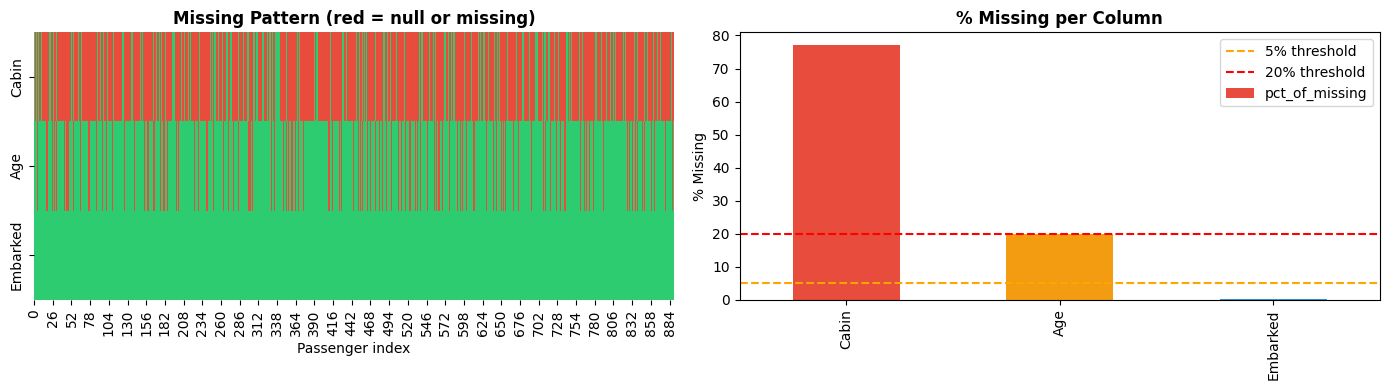

Saved: outputs/p1_missing_analysis.png


In [39]:
# Visualise missing pattern
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Heatmap
miss_matrix = titanic_df[missing.index].isnull().astype(int)
sb.heatmap(miss_matrix.T, cbar=False, yticklabels=True,
            cmap=['#2ecc71','#e74c3c'], ax=axes[0])
axes[0].set_title('Missing Pattern (red = null or missing)', fontweight='bold')
axes[0].set_xlabel('Passenger index')
# Bar chart
missing['pct_of_missing'].plot(kind='bar', ax=axes[1], color=['#e74c3c','#f39c12','#3498db'])
axes[1].set_title('% Missing per Column', fontweight='bold')
axes[1].set_ylabel('% Missing')
axes[1].axhline(5,  color='orange', ls='--', label='5% threshold')
axes[1].axhline(20, color='red',    ls='--', label='20% threshold')
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p1_missing_analysis.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/p1_missing_analysis.png")

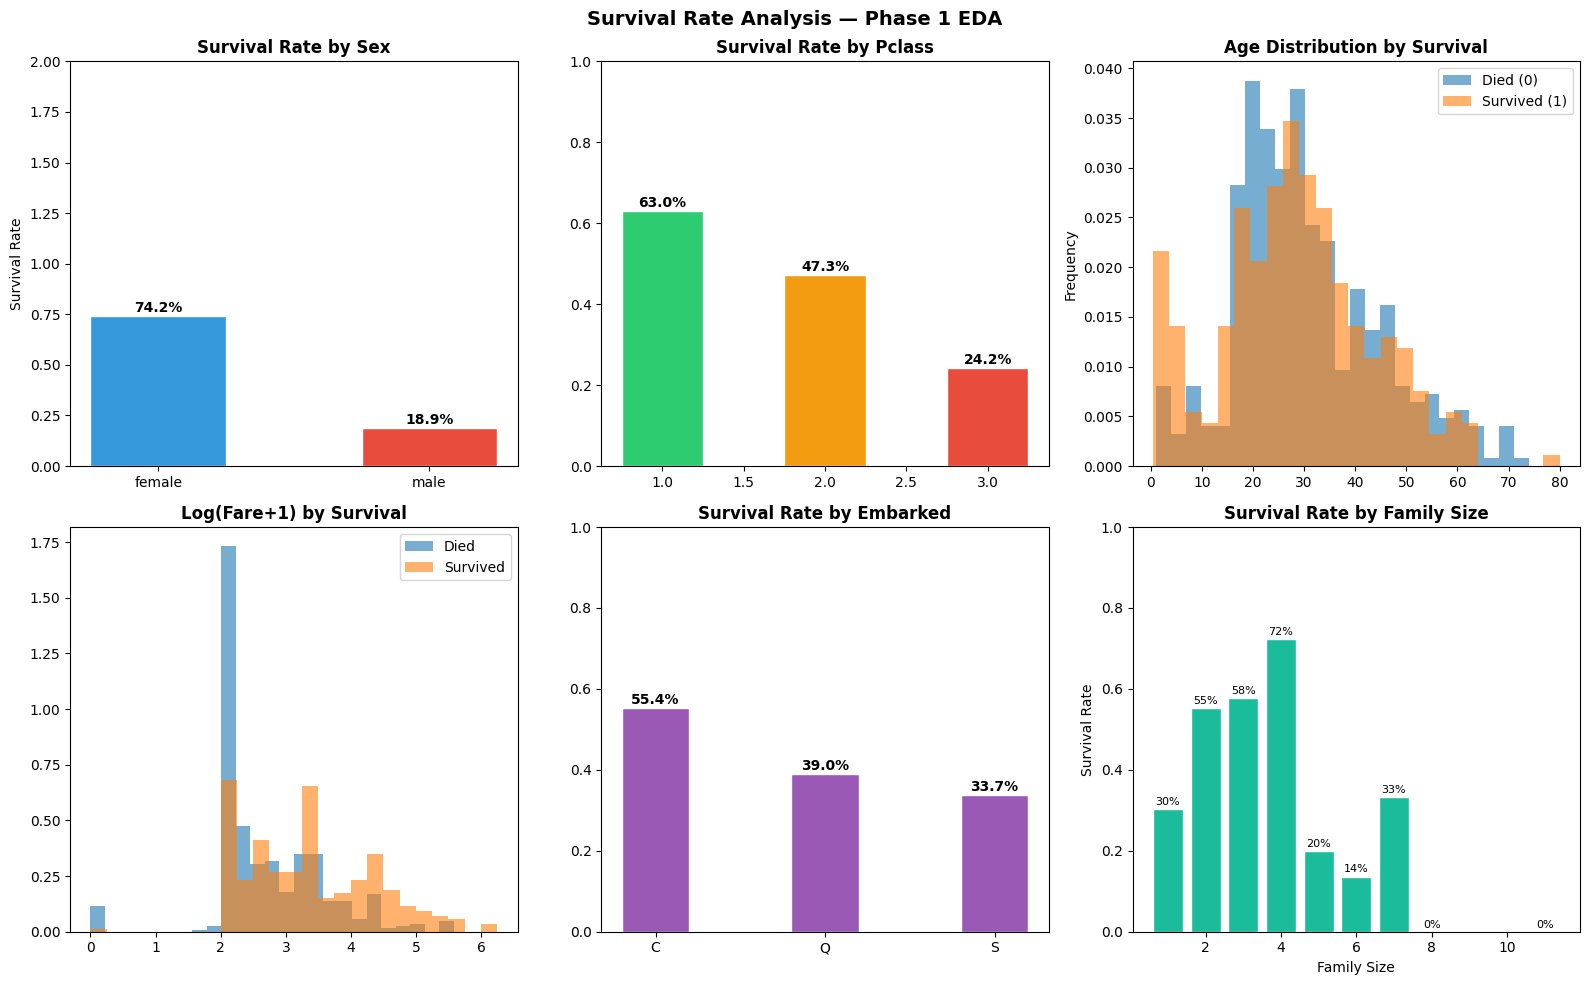

In [40]:
# ── 1.4  Survival rate by every feature ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Survival Rate Analysis — Phase 1 EDA', fontsize=14, fontweight='bold')

# (A) By Sex
surv_sex = titanic_df.groupby('Sex')['Survived'].mean()
axes[0,0].bar(surv_sex.index, surv_sex.values,
              color=['#3498db','#e74c3c'], edgecolor='white', width=0.5)
axes[0,0].set_title('Survival Rate by Sex', fontweight='bold')
axes[0,0].set_ylabel('Survival Rate')
for i,(k,v) in enumerate(surv_sex.items()):
    axes[0,0].text(i, v+0.02, f'{v:.1%}', ha='center', fontweight='bold')
axes[0,0].set_ylim(0,2)

# (B) By Pclass
surv_pc = titanic_df.groupby('Pclass')['Survived'].mean()
colors  = ['#2ecc71','#f39c12','#e74c3c']
axes[0,1].bar(surv_pc.index, surv_pc.values, color=colors, edgecolor='white', width=0.5)
axes[0,1].set_title('Survival Rate by Pclass', fontweight='bold')
for i,(k,v) in enumerate(surv_pc.items()):
    axes[0,1].text(k, v+0.01, f'{v:.1%}', ha='center', fontweight='bold')
axes[0,1].set_ylim(0,1)
# (C) Age distribution by survival
titanic_df.dropna(subset=['Age']).groupby('Survived')['Age'].plot(
    kind='hist', bins=25, alpha=0.6, density=True, ax=axes[0,2])
axes[0,2].set_title('Age Distribution by Survival', fontweight='bold')
axes[0,2].legend(['Died (0)','Survived (1)'])

# (D) Fare distribution (log scale) by survival
for cls in [0,1]:
    vals = np.log1p(titanic_df[titanic_df['Survived']==cls]['Fare'].dropna())
    axes[1,0].hist(vals, bins=25, alpha=0.6, density=True, label=f'{"Survived" if cls else "Died"}')
axes[1,0].set_title('Log(Fare+1) by Survival', fontweight='bold')
axes[1,0].legend()

axes[1,1].set_ylim(0,1)

# (E) Embarked survival
surv_emb = titanic_df.groupby('Embarked')['Survived'].mean().dropna()
axes[1,1].bar(surv_emb.index, surv_emb.values, color='#9b59b6', edgecolor='white', width=0.4)
axes[1,1].set_title('Survival Rate by Embarked', fontweight='bold')
for i,(k,v) in enumerate(surv_emb.items()):
    axes[1,1].text(i, v+0.01, f'{v:.1%}', ha='center', fontweight='bold')
axes[1,1].set_ylim(0,1)

# (F) SibSp+Parch survival heatmap
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1
pivot = titanic_df.groupby('FamilySize')['Survived'].agg(['mean','count'])
pivot.columns = ['SurvRate','Count']
axes[1,2].bar(pivot.index, pivot['SurvRate'], color='#1abc9c', edgecolor='white')
axes[1,2].set_title('Survival Rate by Family Size', fontweight='bold')
axes[1,2].set_xlabel('Family Size')
axes[1,2].set_ylabel('Survival Rate')
axes[1,2].set_ylim(0,1)
for i, row in pivot.iterrows():
    axes[1,2].text(i, row['SurvRate']+0.01, f'{row["SurvRate"]:.0%}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p1_survival_analysis.png', bbox_inches='tight')
plt.show()



In [41]:
titanic_df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658,-0.040143
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.065997
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,-0.301914
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,0.890712
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,0.783111
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,0.217138
FamilySize,-0.040143,0.016639,0.065997,-0.301914,0.890712,0.783111,0.217138,1.000000


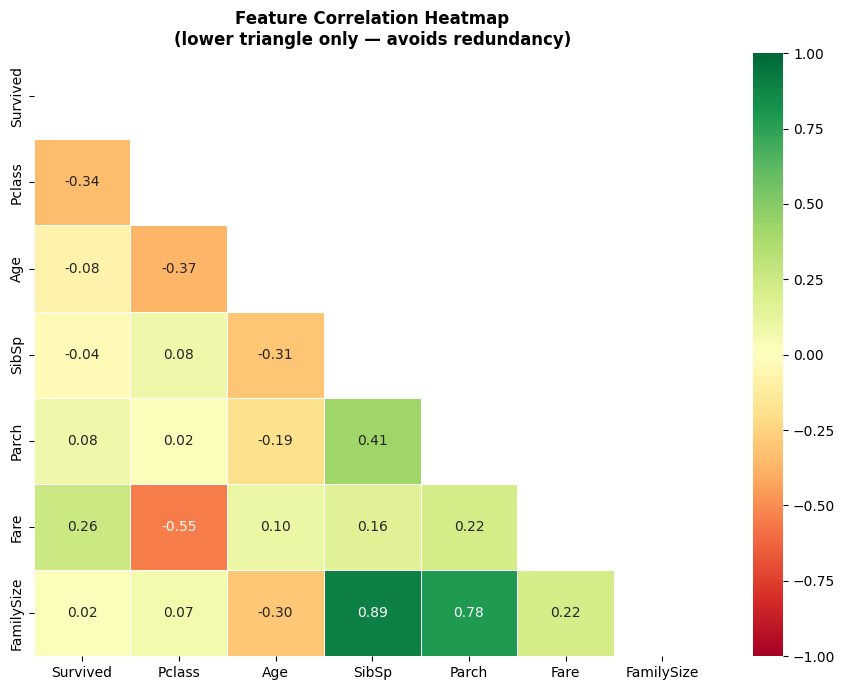

Key correlations with Survived:
Survived      1.000000
Fare          0.257307
Parch         0.081629
FamilySize    0.016639
SibSp        -0.035322
Age          -0.077221
Pclass       -0.338481


In [42]:
# ── 1.5  Correlation heatmap ─────────────────────────────────────────────────
num_for_corr = ['Survived','Pclass','Age','SibSp','Parch','Fare','FamilySize']
corr_matrix  = titanic_df[num_for_corr].corr()

fig, ax = plt.subplots(figsize=(9,7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sb.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size':10})
ax.set_title('Feature Correlation Heatmap\n(lower triangle only — avoids redundancy)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p1_correlation.png', bbox_inches='tight')
plt.show()

print("Key correlations with Survived:")
print(corr_matrix['Survived'].sort_values(ascending=False).to_string())

In [43]:
titanic_df.corr(numeric_only=True)['Survived'].sort_values(ascending=False)

Survived       1.000000
Fare           0.257307
Parch          0.081629
FamilySize     0.016639
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

interpretation 

survived with others. (target with features)


Survived       1.000000.   ---> obviously. it will always correlates to itself

Fare           0.257307.   ---> ≈+0.26 Moderate positive correlation. high fare higher survival

Parch          0.081629.   ---> ≈+0.08 near to zero no strong linear impact. but don't ignore, they may worked better as engineered features
(FamilySize)

FamilySize     0.016639.   ---> ≈+0.01 very near to zero no strong linear impact.

PassengerId   -0.005007.   ---> ≈ -0.005 almost zero. more over passengerId is a unique sequence generated no impact

SibSp         -0.035322.   ---> ≈ -0.03 near to zero no strong linear impact. but don't ignore, they may worked better as engineered features(FamilySize)

Age           -0.077221    ---> ≈ -0.08 Almost no linear relationship, Age alone is not a strong predictor

Pclass        -0.338481.   ---> ≈ -0.34 Moderate negative correlation Lower class → lower survival


Features vs Features

Pclass vs Fare (~ -0.55) --> Strong negative correlation, Higher class (1st) → higher fare, these features are related (multicollinearity risk)
Age vs Pclass (~ -0.37). --> Moderate negative. correlation Higher class passengers tend to be older (no need to confuse here as class 1-socioeconomic wealthy,2--> moderate afforable class,  3--normal or poor people)
SibSp vs Parch (~ 0.41) --> Families travel together

| Correlation | Strength |
| ----------- | -------- |
| 0.00–0.10   | None     |
| 0.10–0.30   | Weak     |
| 0.30–0.50   | Moderate |
| 0.50+       | Strong   |


intake:   Correlation analysis shows that survival is moderately associated with passenger class and fare, indicating a strong socioeconomic influence. Age and family-related features show weak linear relationships, suggesting they may require feature engineering or interaction terms. Additionally, Pclass and Fare are highly correlated, indicating potential redundancy.”

---
# Phase 2 — Feature Engineering

## 📘 Theory: Feature Engineering Principles

> Feature engineering is the process of using domain knowledge to transform
> raw variables into representations that better capture signal for the model.
>
> **The 5 FE patterns covered here:**
>
> | Pattern | Example | Benefit |
> |---------|---------|---------|
> | **Extraction** | `Title` from `Name` | Encode domain knowledge (gender+status) |
> | **Binning (non-linear)** | `FamilyBin` from `FamilySize` | Capture U-shaped relationship |
> | **Binary Flag from MNAR** | `HasCabin` from `Cabin` | Missing-ness IS the signal |
> | **Log Transform** | `log1p(Fare)` | Reduce right-skew, stabilise variance |
> | **Group Imputation** | Age by Pclass+Sex median | Smarter than global mean |
>
> 🏭 **Industry Note**: Feature engineering typically accounts for 60–80% of
> model performance improvement — far more than algorithm choice.

real-world FE is:

👉 Combination of:

Math (transforms)

Statistics (distributions)

ML (clustering, encoding)

Domain knowledge (most important)

🔷 1. Interaction Features (Feature Crossing)

🔷 2. Polynomial Features

🔷 3. Encoding Techniques (Very Important)

        Lable Encoding

        One-Hot Encoding

        Target Encoding (Advanced)

🔷 4. Aggregation Features

🔷 5. Ratio / Normalization Features

🔷 6. Ranking / Ordering Features

🔷 7. Frequency Encoding

🔷 8. Count-Based Features

🔷 9. Text Feature Engineering

🔷 10. Date/Time Features



🔷 11. Scaling / Normalization

🔷 12. Outlier Treatment Features

🔷 13. Missing Value Features (Extended)

🔷 14. Clustering-Based Features

🔷 15. Dimensionality Reduction Features

🔷 16. Statistical Features (Advanced)

🔷 17. Window / Rolling Features (Time Series)

🔷 18. Domain-Specific Features (Most Powerful)

🔷 19. Feature Selection (Indirect FE)

🔷 20. Model-Based Features

In [44]:
# ── 2.1  Title Extraction ────────────────────────────────────────────────────
def extract_title(name):
    """Extract title from 'Lastname, Title. Firstname' format."""
    import re
    match = re.search(r',\s*([^.]+)\.', str(name))
    if match:
        title = match.group(1).strip()
        rare  = {'Don','Rev','Dr','Major','Lady','Sir','Col','Capt',
                 'Countess','Jonkheer','Mme','Ms','Mlle'}
        if title in rare: return 'Rare'
        return title
    return 'Unknown'

titanic_df['Title'] = titanic_df['Name'].apply(extract_title)
print("Title distribution:")
print(titanic_df['Title'].value_counts().to_string())
print()
print("Survival rate by Title:")
print(titanic_df.groupby('Title')['Survived'].agg(['mean','count']).round(3).to_string())

Title distribution:
Title
Mr              517
Miss            182
Mrs             125
Master           40
Rare             26
the Countess      1

Survival rate by Title:
               mean  count
Title                     
Master        0.575     40
Miss          0.698    182
Mr            0.157    517
Mrs           0.792    125
Rare          0.423     26
the Countess  1.000      1


In [45]:
# ── 2.2  FamilySize → non-linear FamilyBin ──────────────────────────────────
# FamilySize already created in Phase 1
# The survival curve is U-shaped: alone=bad, small=good, large=bad
def family_bin(size):
    if size == 1: return 'Alone'
    if size <= 4: return 'Small'
    return 'Large'

titanic_df['FamilyBin'] = titanic_df['FamilySize'].apply(family_bin)

# Validate the non-linearity
print("Survival by FamilyBin:")
fb_surv = titanic_df.groupby('FamilyBin')['Survived'].agg(['mean','count'])
print(fb_surv)
print()
print("WHY non-linear binning? — if we kept FamilySize as numeric,")
print("linear models assume monotone relationship, missing the peak at size 2-4")

Survival by FamilyBin:
               mean  count
FamilyBin                 
Alone      0.303538    537
Large      0.161290     62
Small      0.578767    292

WHY non-linear binning? — if we kept FamilySize as numeric,
linear models assume monotone relationship, missing the peak at size 2-4


In [46]:
# ── 2.3  HasCabin — MNAR Binary Flag ────────────────────────────────────────
titanic_df['HasCabin'] = titanic_df['Cabin'].notna().astype(int)
print("HasCabin survival comparison:")
print(titanic_df.groupby('HasCabin')['Survived'].agg(['mean','count']).rename(
    index={0:'No Cabin (MNAR)', 1:'Has Cabin'}))
print()
print("If we just dropped Cabin, we'd lose this ~15pp survival signal.")

HasCabin survival comparison:
                     mean  count
HasCabin                        
No Cabin (MNAR)  0.299854    687
Has Cabin        0.666667    204

If we just dropped Cabin, we'd lose this ~15pp survival signal.


In [47]:
titanic_df.groupby('HasCabin')['Survived'].agg(['mean','count'])

,mean,count
HasCabin,,
0,0.299854,687
1,0.666667,204


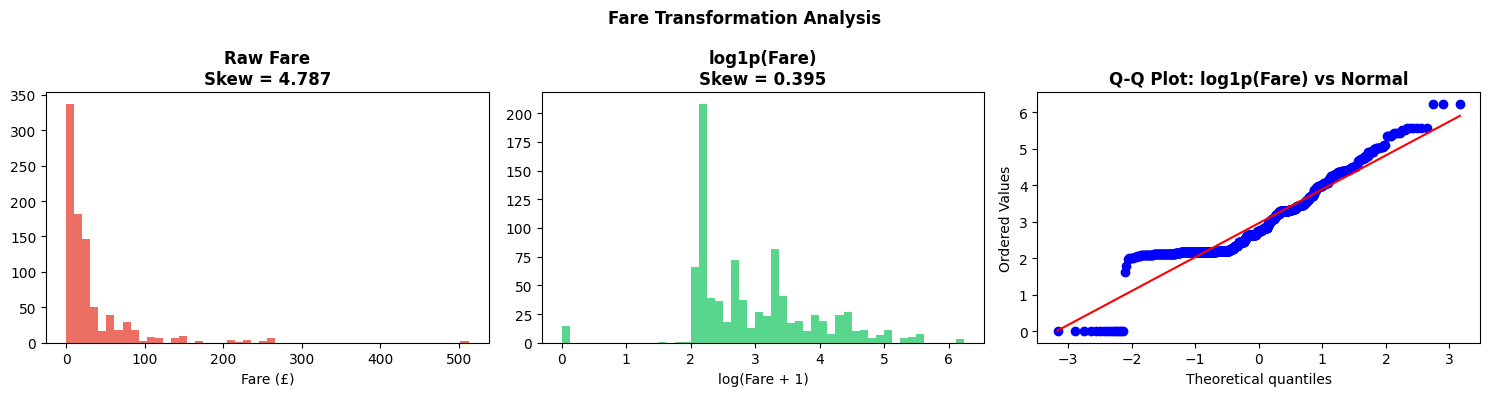

Skew before: 4.787  →  after log1p: 0.395


In [48]:
from scipy import stats 

# ── 2.4  Fare: Log1p Transform ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Fare Transformation Analysis', fontweight='bold')

# Raw
axes[0].hist(titanic_df['Fare'].dropna(), bins=50, color='#e74c3c', edgecolor='none', alpha=0.8)
axes[0].set_title(f'Raw Fare\nSkew = {titanic_df["Fare"].skew():.3f}', fontweight='bold')
axes[0].set_xlabel('Fare (£)')

# Log1p
titanic_df['Fare_log'] = np.log1p(titanic_df['Fare'])
axes[1].hist(titanic_df['Fare_log'].dropna(), bins=50, color='#2ecc71', edgecolor='none', alpha=0.8)
axes[1].set_title(f'log1p(Fare)\nSkew = {titanic_df["Fare_log"].skew():.3f}', fontweight='bold')
axes[1].set_xlabel('log(Fare + 1)')

# QQ plot of log-transformed
stats.probplot(titanic_df['Fare_log'].dropna(), plot=axes[2])
axes[2].set_title('Q-Q Plot: log1p(Fare) vs Normal', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p2_fare_transform.png', bbox_inches='tight')
plt.show()
print(f"Skew before: {titanic_df['Fare'].skew():.3f}  →  after log1p: {titanic_df['Fare_log'].skew():.3f}")

## 📘 Theory: Why log1p and not log?

> - `np.log(0)` = **-infinity** → crashes if any Fare = 0
> - `np.log1p(x)` = `log(x + 1)` → safe for zero values
> - Also numerically stable for very small values
> - After transform: model sees roughly equal spacing between fare bands
> - **Industry rule**: Apply to any feature with skew > 1.0

In [49]:
# ── 2.5  Age Imputation — Group Median by Pclass + Sex ───────────────────────
print("Why group-median over global median?")
print()
print("Age median by Pclass × Sex group:")
age_medians = titanic_df.groupby(['Pclass','Sex'])['Age'].median().round(1)
print(age_medians.to_string())

print()
global_med = titanic_df['Age'].median()
print(f"Global median: {global_med:.1f}")
print()
print("A 1st-class woman has very different expected age than a 3rd-class boy.")
print("Using global median ignores this — group median is far more accurate.")

# Impute
titanic_df['Age_imputed'] = titanic_df.groupby(['Pclass','Sex'])['Age'].transform(
    lambda x: x.fillna(x.median()))

print(f"\nMissing Age before: {titanic_df['Age'].isnull().sum()}")
print(f"Missing Age after:  {titanic_df['Age_imputed'].isnull().sum()}")

Why group-median over global median?

Age median by Pclass × Sex group:
Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0

Global median: 28.0

A 1st-class woman has very different expected age than a 3rd-class boy.
Using global median ignores this — group median is far more accurate.

Missing Age before: 177
Missing Age after:  0


In [50]:
# ── 2.6  Final Feature Assembly ──────────────────────────────────────────────
titanic_df['Embarked_filled'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])
titanic_df['IsCrew']          = (titanic_df['Fare'] == 0).astype(int)

# One-hot encode
df_eng = pd.get_dummies(titanic_df[[
    'Survived','Pclass','Sex','Age_imputed','SibSp','Parch',
    'Fare_log','HasCabin','IsCrew','FamilySize','FamilyBin',
    'Title','Embarked_filled'
]], columns=['Sex','FamilyBin','Title','Embarked_filled'], drop_first=False)

# Drop one dummy per group to avoid multicollinearity
cols_to_drop = [c for c in df_eng.columns if c.endswith('_male') or
                c.endswith('_Alone') or c.endswith('_Mr.') or c.endswith('_S')]
df_eng.drop(columns=[c for c in cols_to_drop if c in df_eng.columns], inplace=True)

print(f"Feature matrix shape: {df_eng.shape}")
print(f"\nFeatures ({df_eng.shape[1]-1} predictors):")
feat_cols = [c for c in df_eng.columns if c != 'Survived']
for i, f in enumerate(feat_cols, 1):
    print(f"  {i:2d}. {f}")

Feature matrix shape: (891, 20)

Features (19 predictors):
   1. Pclass
   2. Age_imputed
   3. SibSp
   4. Parch
   5. Fare_log
   6. HasCabin
   7. IsCrew
   8. FamilySize
   9. Sex_female
  10. FamilyBin_Large
  11. FamilyBin_Small
  12. Title_Master
  13. Title_Miss
  14. Title_Mr
  15. Title_Mrs
  16. Title_Rare
  17. Title_the Countess
  18. Embarked_filled_C
  19. Embarked_filled_Q


In [51]:
# ── 2.7  Train / Test Split (stratified) ────────────────────────────────────
SEED=42
X = df_eng.drop('Survived', axis=1)
y = df_eng['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f"Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print(f"Train survival rate: {y_train.mean():.1%}  |  Test: {y_test.mean():.1%}")
print("\nStratified split ensures train/test have same class proportions ✅")

Train: 712 rows  |  Test: 179 rows
Train survival rate: 38.3%  |  Test: 38.5%

Stratified split ensures train/test have same class proportions ✅


# Phase 3 — Baseline Modeling: Logistic Regression


Logistic Regression as a Baseline

> **Always start with the simplest interpretable model.**
> Logistic Regression gives you:
>
> 1. A performance **floor** — every other model must beat this
> 2. **Coefficient interpretation** — which features matter and in what direction
> 3. **Multicollinearity detection** — sign flips, unexpected coefficients
> 4. Fast training → quick iteration cycle
>
> The logistic function: `P(y=1) = 1 / (1 + e^(-z))` where `z = β₀ + β₁x₁ + ...`
>
> **Coefficient interpretation:**
> - Positive β → feature increases P(survive)
> - |β| = magnitude of effect (after standardisation)
> - Sign flip from EDA expectation → multicollinearity warning

In [52]:

# ── 3.1  Logistic Regression Baseline ───────────────────────────────────────
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
lr.fit(X_train_s, y_train)

y_pred   = lr.predict(X_test_s)
y_proba  = lr.predict_proba(X_test_s)[:,1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
f1  = f1_score(y_test, y_pred)

print(f"{'='*45}")
print(f"  LOGISTIC REGRESSION — BASELINE RESULTS")
print(f"{'='*45}")
print(f"  Accuracy  : {acc:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"{'='*45}")
print()
print(classification_report(y_test, y_pred, target_names=['Died','Survived']))

  LOGISTIC REGRESSION — BASELINE RESULTS
  Accuracy  : 0.8380
  AUC-ROC   : 0.8661
  F1-Score  : 0.7883

              precision    recall  f1-score   support

        Died       0.86      0.87      0.87       110
    Survived       0.79      0.78      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



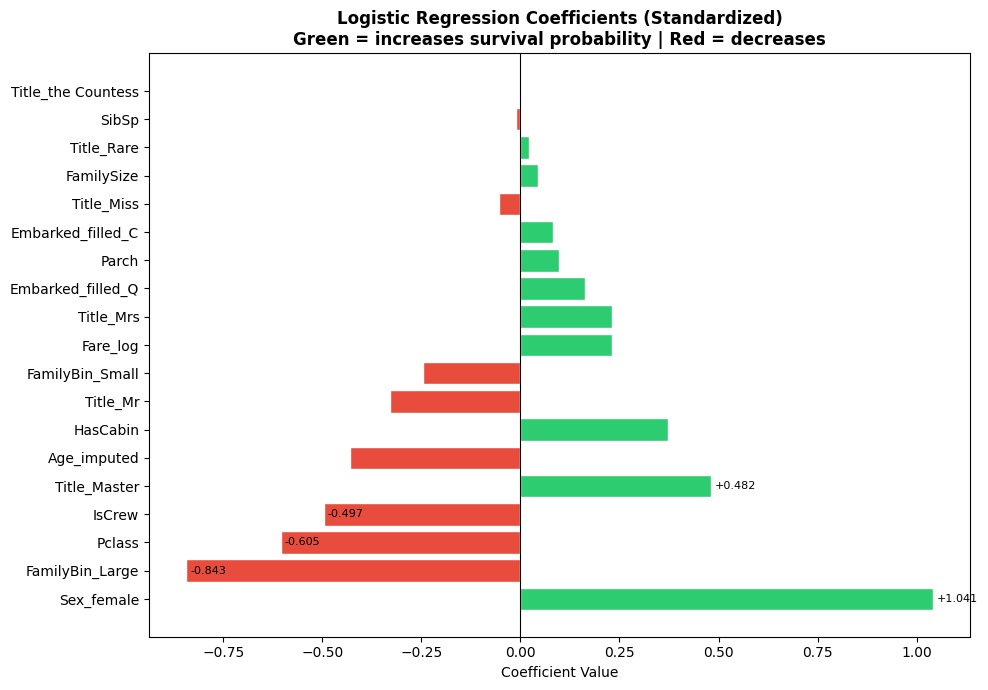


Top 5 most influential features (by |coefficient|):
        feature  coefficient
     Sex_female     1.041338
FamilyBin_Large    -0.842845
         Pclass    -0.604984
         IsCrew    -0.496595
   Title_Master     0.481795

⚠️  Industry Note: Sex and Title features are correlated.
   This causes the Sex coefficient to appear unexpectedly small —
   Title (Mr/Mrs/Miss) already encodes gender implicitly.
   This is multicollinearity — always check when coefficients surprise you.


In [53]:
# ── 3.2  Coefficient Interpretation + Multicollinearity Lesson ──────────────
coef_df = pd.DataFrame({
    'feature'    : X_train.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients (Standardized)\n'
             'Green = increases survival probability | Red = decreases',
             fontweight='bold')
ax.set_xlabel('Coefficient Value')

# Annotate key ones
for _, row in coef_df.head(5).iterrows():
    ax.text(row['coefficient'] + 0.01, row['feature'],
            f'{row["coefficient"]:+.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p3_lr_coefficients.png', bbox_inches='tight')
plt.show()

print("\nTop 5 most influential features (by |coefficient|):")
print(coef_df.head(5).to_string(index=False))
print()
print("⚠️  Industry Note: Sex and Title features are correlated.")
print("   This causes the Sex coefficient to appear unexpectedly small —")
print("   Title (Mr/Mrs/Miss) already encodes gender implicitly.")
print("   This is multicollinearity — always check when coefficients surprise you.")

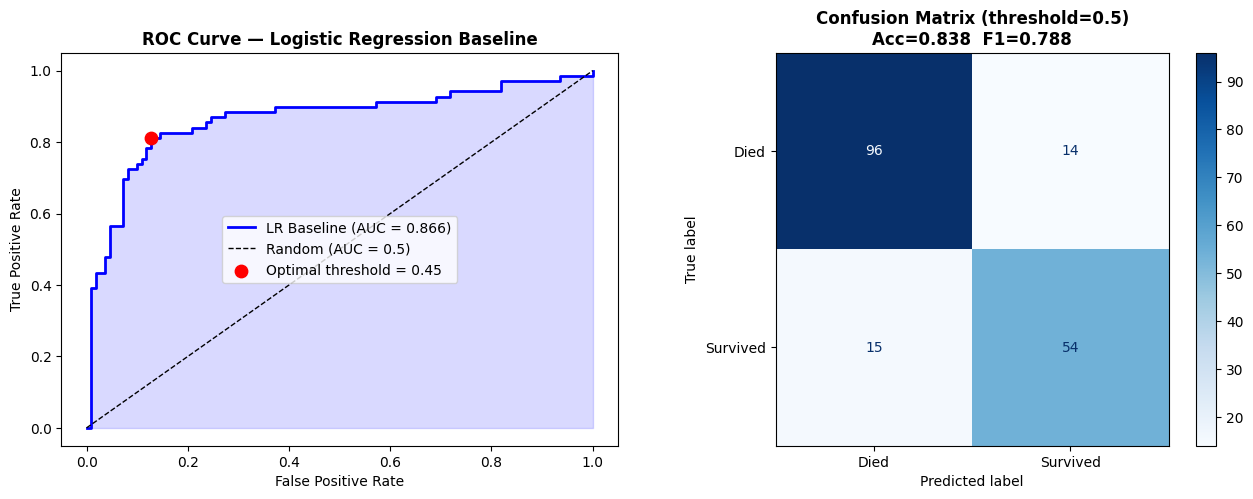

Optimal threshold (Youden's J): 0.455
At 0.5 threshold: 14 false alarms, 15 missed survivors


In [54]:
# ── 3.3  ROC Curve + Confusion Matrix ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, 'b-', lw=2, label=f'LR Baseline (AUC = {auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1, label='Random (AUC = 0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.15, color='blue')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Logistic Regression Baseline', fontweight='bold')
axes[0].legend(loc='lower right')

# Optimal threshold by Youden's J
youden_j = tpr - fpr
opt_idx  = np.argmax(youden_j)
opt_thr  = thresholds[opt_idx]
axes[0].scatter(fpr[opt_idx], tpr[opt_idx], s=80, color='red',
                zorder=5, label=f'Optimal threshold = {opt_thr:.2f}')
axes[0].legend()

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
    display_labels=['Died','Survived'], cmap='Blues', ax=axes[1])
axes[1].set_title(f'Confusion Matrix (threshold=0.5)\nAcc={acc:.3f}  F1={f1:.3f}',
                  fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p3_roc_confusion.png', bbox_inches='tight')
plt.show()
print(f"Optimal threshold (Youden's J): {opt_thr:.3f}")
print(f"At 0.5 threshold: {confusion_matrix(y_test,y_pred)[0,1]} false alarms, {confusion_matrix(y_test,y_pred)[1,0]} missed survivors")

---
# Phase 4 — Algorithm Comparison (6 Models, 5-Fold CV)

In [55]:
# ── 4.1  Define all 6 algorithms ─────────────────────────────────────────────
algorithms = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree'      : DecisionTreeClassifier(random_state=SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'SVM'                : SVC(probability=True, random_state=SEED),
    'KNN'                : KNeighborsClassifier(),
    'XGBoost'            : XGBClassifier(random_state=SEED, eval_metric='logloss',
                                          verbosity=0, n_jobs=-1),
}

# Algorithms needing scaling
needs_scale = {'Logistic Regression', 'SVM', 'KNN'}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("Running 5-fold cross-validation on all 6 algorithms...")
print("(This may take 30–60 seconds)")

Running 5-fold cross-validation on all 6 algorithms...
(This may take 30–60 seconds)


In [56]:
# ── 4.2  Run CV comparison ───────────────────────────────────────────────────
results = {}
for name, model in algorithms.items():
    if name in needs_scale:
        from sklearn.pipeline import make_pipeline
        pipe = make_pipeline(StandardScaler(), model)
    else:
        pipe = model

    # Multiple metrics via cross_val_score
    acc_scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                                  scoring='accuracy', n_jobs=-1)
    auc_scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                                  scoring='roc_auc', n_jobs=-1)
    f1_scores  = cross_val_score(pipe, X_train, y_train, cv=cv,
                                  scoring='f1', n_jobs=-1)

    results[name] = {
        'acc_mean' : acc_scores.mean(), 'acc_std': acc_scores.std(),
        'auc_mean' : auc_scores.mean(), 'auc_std': auc_scores.std(),
        'f1_mean'  : f1_scores.mean(),  'f1_std' : f1_scores.std(),
    }
    print(f"  {name:<22}  Acc={acc_scores.mean():.4f}±{acc_scores.std():.4f}  "
          f"AUC={auc_scores.mean():.4f}  F1={f1_scores.mean():.4f}")

results_df = pd.DataFrame(results).T
print("\n5-Fold CV Results Summary:")
print(results_df[['acc_mean','auc_mean','f1_mean','acc_std']].round(4).sort_values('auc_mean',ascending=False).to_string())

  Logistic Regression     Acc=0.8329±0.0244  AUC=0.8792  F1=0.7801
  Decision Tree           Acc=0.7753±0.0289  AUC=0.7620  F1=0.7092
  Random Forest           Acc=0.8245±0.0225  AUC=0.8755  F1=0.7665
  SVM                     Acc=0.8315±0.0237  AUC=0.8682  F1=0.7670
  KNN                     Acc=0.8203±0.0238  AUC=0.8566  F1=0.7578
  XGBoost                 Acc=0.8132±0.0234  AUC=0.8850  F1=0.7481

5-Fold CV Results Summary:
                     acc_mean  auc_mean  f1_mean  acc_std
XGBoost                0.8132    0.8850   0.7481   0.0234
Logistic Regression    0.8329    0.8792   0.7801   0.0244
Random Forest          0.8245    0.8755   0.7665   0.0225
SVM                    0.8315    0.8682   0.7670   0.0237
KNN                    0.8203    0.8566   0.7578   0.0238
Decision Tree          0.7753    0.7620   0.7092   0.0289


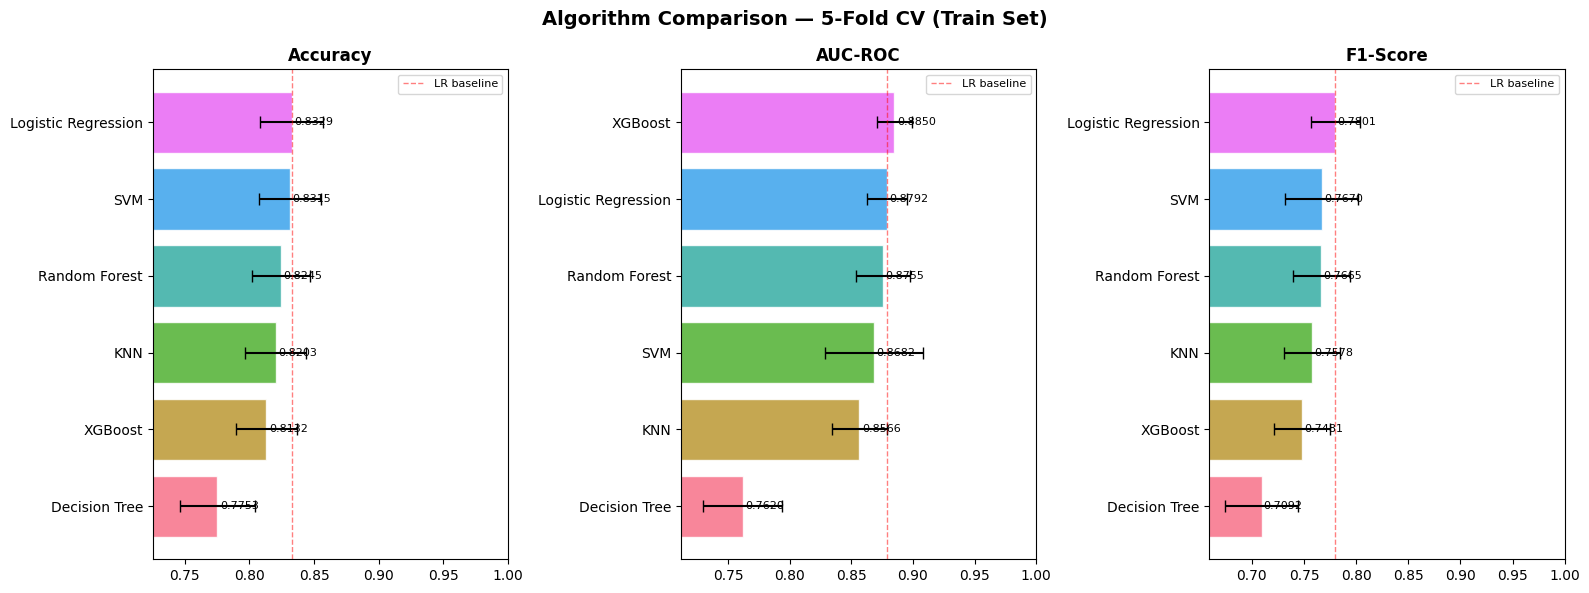

In [57]:
# ── 4.3  Comparison Visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Algorithm Comparison — 5-Fold CV (Train Set)', fontsize=14, fontweight='bold')

metrics = [('acc_mean','acc_std','Accuracy'), ('auc_mean','auc_std','AUC-ROC'), ('f1_mean','f1_std','F1-Score')]
palette = sb.color_palette('husl', len(results_df))

for ax, (mean_col, std_col, title) in zip(axes, metrics):
    sorted_df = results_df.sort_values(mean_col, ascending=True)
    bars = ax.barh(sorted_df.index, sorted_df[mean_col], 
                   xerr=sorted_df[std_col], capsize=4,
                   color=palette, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(sorted_df[mean_col].min() - 0.05, 1.0)
    ax.axvline(results_df.loc['Logistic Regression',mean_col], 
               color='red', ls='--', lw=1, alpha=0.5, label='LR baseline')
    for bar, val in zip(bars, sorted_df[mean_col]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p4_algorithm_comparison.png', bbox_inches='tight')
plt.show()

---
# Phase 5 — Learning Curves & Bias-Variance Diagnosis

Theory: Learning Curves & the Bias-Variance Trade-off

> A **learning curve** plots model performance as training size increases.
> The gap between train and validation score diagnoses the problem:
>
> ```
> HIGH BIAS (Underfitting)         HIGH VARIANCE (Overfitting)
> ─────────────────────────         ─────────────────────────
> Train  score: LOW  (e.g. 0.75)   Train  score: HIGH (e.g. 0.98)
> Valid  score: LOW  (e.g. 0.74)   Valid  score: LOW  (e.g. 0.80)
> Gap         : tiny               Gap         : LARGE
> Converges   : both plateau low   Converges   : not yet converged
> Fix         : more features,     Fix         : more data, regularise,
>               complex model                  prune, dropout
> ```
>
> **Key insight**: If both curves converge to the same low value →
> more data won't help. You need a better model or more features.

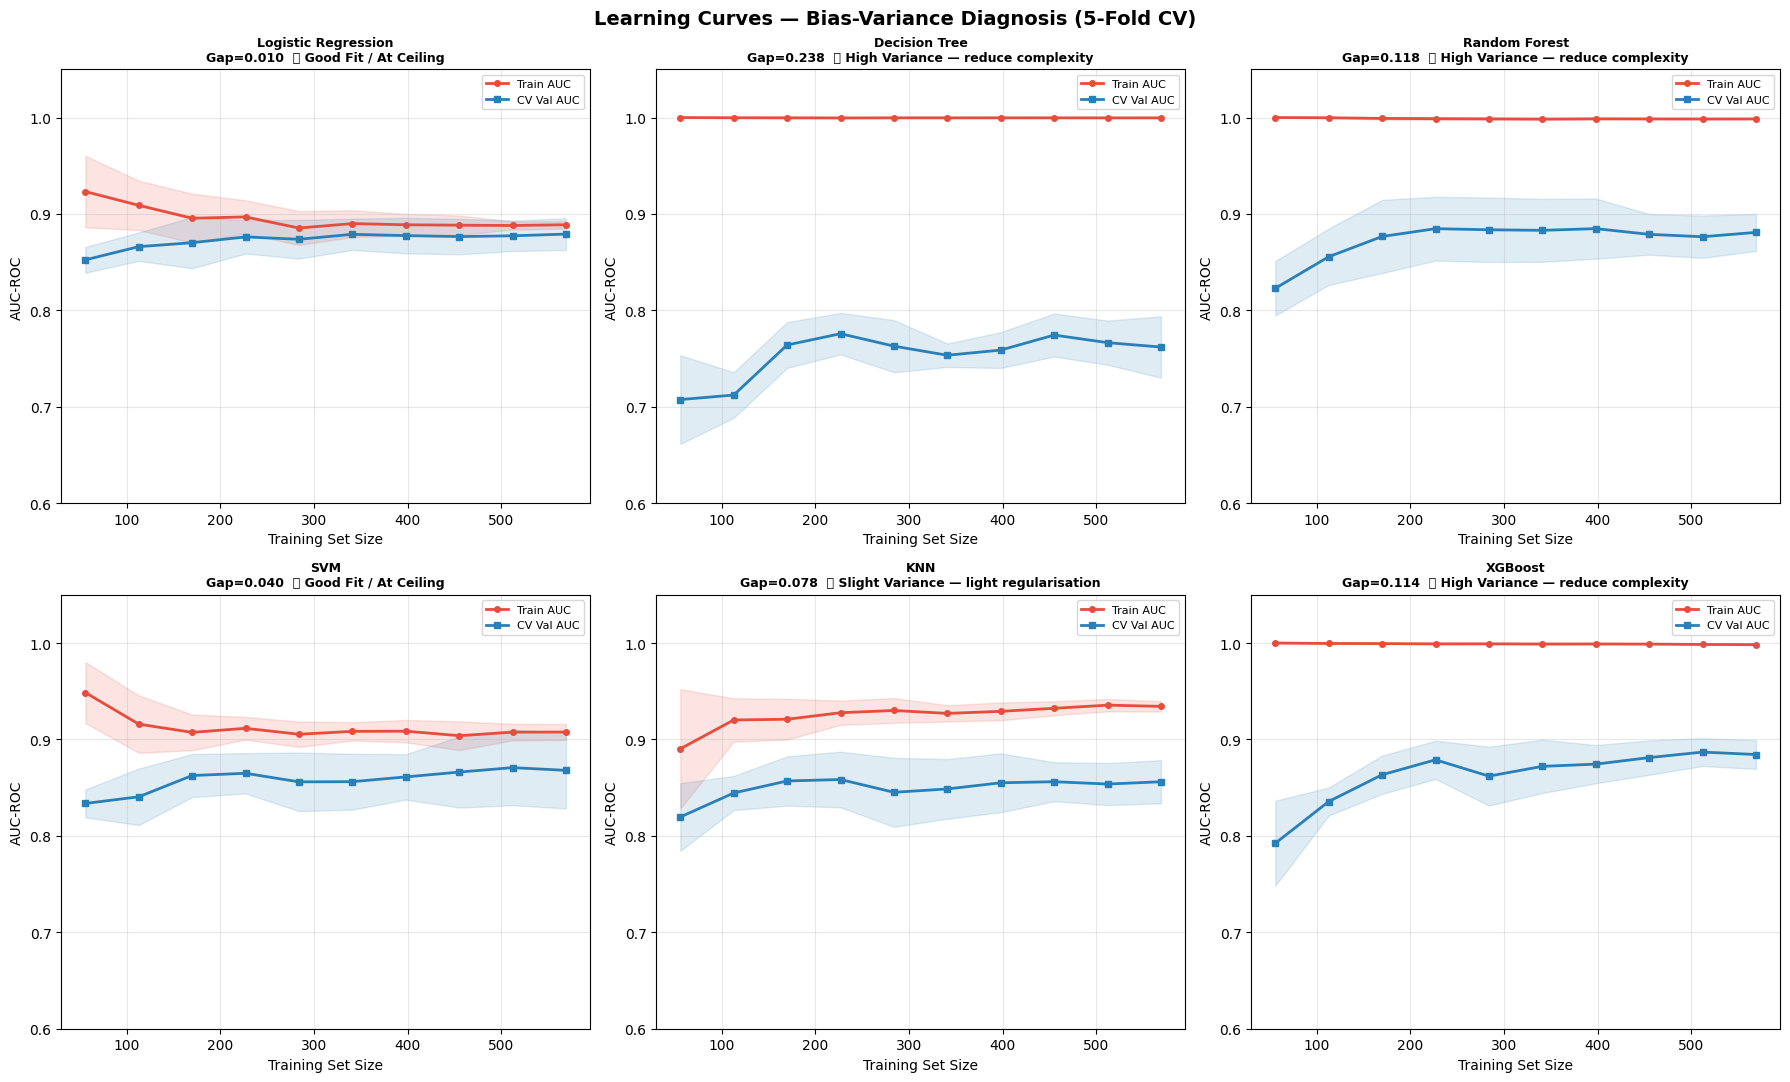

Analysis complete — see titles for bias/variance diagnosis per model


In [58]:
# ── 5.1  Learning curves for all 6 models ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Learning Curves — Bias-Variance Diagnosis (5-Fold CV)',
             fontsize=14, fontweight='bold')

train_sizes_abs = np.linspace(0.10, 1.0, 10)

for ax, (name, model) in zip(axes.flat, algorithms.items()):
    if name in needs_scale:
        from sklearn.pipeline import make_pipeline
        pipe = make_pipeline(StandardScaler(), model)
    else:
        pipe = model

    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X_train, y_train,
        train_sizes=train_sizes_abs, cv=cv, scoring='roc_auc',
        n_jobs=-1, shuffle=True, random_state=SEED)

    t_mean, t_std = train_scores.mean(1), train_scores.std(1)
    v_mean, v_std = val_scores.mean(1), val_scores.std(1)

    ax.plot(train_sizes, t_mean, 'o-', color='#e74c3c', lw=2, ms=4, label='Train AUC')
    ax.plot(train_sizes, v_mean, 's-', color='#2980b9', lw=2, ms=4, label='CV Val AUC')
    ax.fill_between(train_sizes, t_mean-t_std, t_mean+t_std, alpha=0.15, color='#e74c3c')
    ax.fill_between(train_sizes, v_mean-v_std, v_mean+v_std, alpha=0.15, color='#2980b9')

    gap = t_mean[-1] - v_mean[-1]
    diagnosis = ('🔴 High Variance — reduce complexity' if gap > 0.10 else
                 '🟡 Slight Variance — light regularisation' if gap > 0.05 else
                 '🟢 Good Fit / At Ceiling')

    ax.set_title(f'{name}\nGap={gap:.3f}  {diagnosis}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Training Set Size'); ax.set_ylabel('AUC-ROC')
    ax.set_ylim(0.60, 1.05); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p5_learning_curves.png', bbox_inches='tight')
plt.show()
print("Analysis complete — see titles for bias/variance diagnosis per model")

---
# Phase 6 — Hyperparameter Tuning

## 📘 Theory: GridSearchCV vs RandomizedSearchCV

> **GridSearchCV**: Exhaustive search over all combinations.
> - Guarantees finding the best in the grid
> - Expensive: 10 params × 5 folds × 5 values each = 250 fits
> - Best for: small grids, final fine-tuning
>
> **RandomizedSearchCV**: Samples n_iter combinations randomly.
> - Faster: you control cost with n_iter
> - Often finds 90%+ of GridSearch quality in 10% of time
> - Best for: large search spaces, initial exploration
>
> **Industry Strategy: Coarse → Fine**
> 1. RandomizedSearch over wide ranges → find promising region
> 2. GridSearch over narrow range around best → fine-tune
> 3. Re-fit on full train set with best params

In [59]:
# ── 6.1  XGBoost — Coarse RandomizedSearch ──────────────────────────────────
print("XGBOOST TUNING — Phase 1: Coarse RandomizedSearchCV")
print("=" * 55)

xgb_coarse_grid = {
    'n_estimators'     : [50, 100, 200, 300, 500],
    'max_depth'        : [3, 4, 5, 6, 7, 8],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.15, 0.2, 0.3],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma'            : [0, 0.1, 0.2, 0.5, 1.0],
    'min_child_weight' : [1, 3, 5, 7],
    'reg_alpha'        : [0, 0.01, 0.1, 1.0],
    'reg_lambda'       : [0.5, 1.0, 2.0, 5.0],
}

xgb_base = XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0, n_jobs=-1)
random_search = RandomizedSearchCV(
    xgb_base, xgb_coarse_grid, n_iter=60, cv=cv,
    scoring='roc_auc', random_state=SEED, n_jobs=-1, verbose=0)
random_search.fit(X_train, y_train)

print(f"Best coarse AUC: {random_search.best_score_:.4f}")
print(f"Best params: {random_search.best_params_}")

XGBOOST TUNING — Phase 1: Coarse RandomizedSearchCV
Best coarse AUC: 0.8982
Best params: {'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.3, 'gamma': 0.5, 'colsample_bytree': 0.9}


In [60]:
# ── 6.2  XGBoost — Fine GridSearchCV ─────────────────────────────────────────
print("XGBOOST TUNING — Phase 2: Fine GridSearchCV around best params")
best = random_search.best_params_

xgb_fine_grid = {
    'n_estimators'  : sorted(set([max(50, best['n_estimators']-50),
                                   best['n_estimators'],
                                   best['n_estimators']+50])),
    'max_depth'     : sorted(set([max(2, best['max_depth']-1),
                                   best['max_depth'],
                                   best['max_depth']+1])),
    'learning_rate' : sorted(set([max(0.01, best['learning_rate']*0.5),
                                   best['learning_rate'],
                                   best['learning_rate']*1.5])),
}
print(f"Fine grid: {xgb_fine_grid}")

xgb_fine = GridSearchCV(
    XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0,
                  subsample=best['subsample'],
                  colsample_bytree=best['colsample_bytree'],
                  gamma=best['gamma'],
                  min_child_weight=best['min_child_weight'],
                  reg_alpha=best['reg_alpha'],
                  reg_lambda=best['reg_lambda'],
                  n_jobs=-1),
    xgb_fine_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
xgb_fine.fit(X_train, y_train)

print(f"\nBest fine AUC: {xgb_fine.best_score_:.4f}")
print(f"Best final params: {xgb_fine.best_params_}")

xgb_tuned = xgb_fine.best_estimator_
y_pred_xgb   = xgb_tuned.predict(X_test)
y_proba_xgb  = xgb_tuned.predict_proba(X_test)[:,1]
print(f"\nTest Results — Tuned XGBoost:")
print(f"  Accuracy: {accuracy_score(y_test,y_pred_xgb):.4f}")
print(f"  AUC-ROC : {roc_auc_score(y_test,y_proba_xgb):.4f}")
print(f"  F1-Score: {f1_score(y_test,y_pred_xgb):.4f}")

XGBOOST TUNING — Phase 2: Fine GridSearchCV around best params
Fine grid: {'n_estimators': [450, 500, 550], 'max_depth': [4, 5, 6], 'learning_rate': [0.15, 0.3, 0.44999999999999996]}

Best fine AUC: 0.8993
Best final params: {'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 550}

Test Results — Tuned XGBoost:
  Accuracy: 0.8045
  AUC-ROC : 0.8448
  F1-Score: 0.7368


In [61]:
# ── 6.3  Tune all remaining models ──────────────────────────────────────────
print("Tuning Random Forest, SVM, KNN, Decision Tree...")
print()

# Random Forest
rf_grid = {'max_depth':[6,8,10,12,None], 'min_samples_split':[2,5,10],
           'min_samples_leaf':[1,2,4], 'max_features':['sqrt','log2']}
rf_gs = GridSearchCV(RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
                      rf_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_gs.fit(X_train, y_train)
rf_tuned = rf_gs.best_estimator_
print(f"RF    best AUC={rf_gs.best_score_:.4f}  params={rf_gs.best_params_}")

# SVM
svm_grid = {'C':[0.1,1,5,10,20], 'kernel':['rbf','poly'], 'gamma':['scale','auto']}
svm_pipe_gs = GridSearchCV(Pipeline([('sc',StandardScaler()),
                            ('svm',SVC(probability=True,random_state=SEED))]),
                           {'svm__'+k:v for k,v in svm_grid.items()},
                           cv=cv, scoring='roc_auc', n_jobs=-1)
svm_pipe_gs.fit(X_train, y_train)
svm_tuned = svm_pipe_gs.best_estimator_
print(f"SVM   best AUC={svm_pipe_gs.best_score_:.4f}  params={svm_pipe_gs.best_params_}")

# KNN
knn_grid = {'n_neighbors':list(range(3,31,2)), 'weights':['uniform','distance'],
            'metric':['euclidean','manhattan']}
knn_pipe_gs = GridSearchCV(Pipeline([('sc',StandardScaler()),('knn',KNeighborsClassifier())]),
                           {'knn__'+k:v for k,v in knn_grid.items()},
                           cv=cv, scoring='roc_auc', n_jobs=-1)
knn_pipe_gs.fit(X_train, y_train)
knn_tuned = knn_pipe_gs.best_estimator_
print(f"KNN   best AUC={knn_pipe_gs.best_score_:.4f}  params={knn_pipe_gs.best_params_}")

# Decision Tree
dt_grid = {'max_depth':[3,4,5,6,7,8], 'min_samples_split':[2,5,10,20],
           'min_samples_leaf':[1,2,4,8], 'criterion':['gini','entropy']}
dt_gs = GridSearchCV(DecisionTreeClassifier(random_state=SEED),
                      dt_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
dt_gs.fit(X_train, y_train)
dt_tuned = dt_gs.best_estimator_
print(f"DT    best AUC={dt_gs.best_score_:.4f}  params={dt_gs.best_params_}")

Tuning Random Forest, SVM, KNN, Decision Tree...

RF    best AUC=0.8891  params={'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10}
SVM   best AUC=0.8697  params={'svm__C': 1, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}
KNN   best AUC=0.8738  params={'knn__metric': 'manhattan', 'knn__n_neighbors': 15, 'knn__weights': 'uniform'}
DT    best AUC=0.8742  params={'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 8, 'min_samples_split': 2}


In [62]:
# ── 6.4  Before vs After Tuning Comparison ───────────────────────────────────
tuned_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree'      : dt_tuned,
    'Random Forest'      : rf_tuned,
    'SVM'                : svm_tuned,
    'KNN'                : knn_tuned,
    'XGBoost'            : xgb_tuned,
}

print("Final Test Set Evaluation — All Tuned Models")
print("=" * 65)
print(f"{'Model':<22}  {'Accuracy':>8}  {'AUC-ROC':>8}  {'F1':>8}  {'Precision':>9}  {'Recall':>7}")
print("-" * 65)

final_results = {}
for name, model in tuned_models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_s, y_train)
        yp  = model.predict(X_test_s)
        ypr = model.predict_proba(X_test_s)[:,1]
    else:
        model.fit(X_train, y_train)
        yp  = model.predict(X_test)
        ypr = model.predict_proba(X_test)[:,1]

    from sklearn.metrics import precision_score, recall_score
    final_results[name] = {
        'Accuracy' : accuracy_score(y_test, yp),
        'AUC'      : roc_auc_score(y_test, ypr),
        'F1'       : f1_score(y_test, yp),
        'Precision': precision_score(y_test, yp),
        'Recall'   : recall_score(y_test, yp),
        'model'    : model, 'y_pred': yp, 'y_proba': ypr
    }
    r = final_results[name]
    print(f"{name:<22}  {r['Accuracy']:>8.4f}  {r['AUC']:>8.4f}  {r['F1']:>8.4f}  {r['Precision']:>9.4f}  {r['Recall']:>7.4f}")

Final Test Set Evaluation — All Tuned Models
Model                   Accuracy   AUC-ROC        F1  Precision   Recall
-----------------------------------------------------------------
Logistic Regression       0.8380    0.8661    0.7883     0.7941   0.7826
Decision Tree             0.7542    0.8167    0.6615     0.7049   0.6232
Random Forest             0.7989    0.8510    0.7273     0.7619   0.6957
SVM                       0.8156    0.8567    0.7519     0.7812   0.7246
KNN                       0.7933    0.8383    0.7132     0.7667   0.6667
XGBoost                   0.8045    0.8448    0.7368     0.7656   0.7101


---
# Phase 7 — Production Pipelines

## 📘 Theory: Why sklearn Pipelines?

> A Pipeline chains preprocessing + model into a **single object** that:
>
> 1. **Prevents data leakage** — fit() on train only, transform() on test
> 2. **Enables CV correctly** — each fold's preprocessing is independent
> 3. **Simplifies deployment** — one `.pkl` file handles everything
> 4. **Enables GridSearch on preprocessing params** — e.g., tune imputation strategy
>
> **Data leakage** is when test-set information contaminates training.
> Classic mistake: `scaler.fit(X_all)` before splitting → test stats leak into train.
> A Pipeline makes this impossible — `.fit()` only ever sees training data.
>
> 🏭 **Industry Note**: At companies like Uber, Google, Airbnb, every model
> in production is a Pipeline. Raw data goes in, predictions come out.
> No manual preprocessing at inference time.

In [63]:
# ── 7.1  Custom Feature Engineering Transformer ──────────────────────────────
class TitanicFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    sklearn-compatible transformer that performs all Titanic feature engineering.
    Accepts raw DataFrame → returns engineered feature matrix.

    Implements fit/transform interface:
    - fit()      : learn imputation statistics from training data only
    - transform(): apply learned stats + deterministic FE to any split
    """

    def __init__(self):
        self.age_medians_    = None
        self.fare_median_    = None
        self.embarked_mode_  = None
        self.feature_names_  = None

    def fit(self, X, y=None):
        df = X.copy()
        # Learn statistics from TRAINING DATA ONLY
        self.age_medians_   = df.groupby(['Pclass','Sex'])['Age'].median()
        self.fare_median_   = df['Fare'].median()
        self.embarked_mode_ = df['Embarked'].mode()[0]
        return self

    def _extract_title(self, name):
        import re
        match = re.search(r',\s*([^.]+)\.', str(name))
        if match:
            title = match.group(1).strip()
            if title in {'Don','Rev','Dr','Major','Lady','Sir','Col',
                         'Capt','Countess','Jonkheer','Mme','Ms','Mlle'}:
                return 'Rare'
            return title
        return 'Mr'

    def transform(self, X, y=None):
        df = X.copy()

        # Title
        df['Title'] = df['Name'].apply(self._extract_title)
        df['Title'] = df['Title'].map(
            lambda t: t if t in ['Mr','Mrs','Miss','Master','Rare'] else 'Rare')

        # Family features
        df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
        df['FamilyBin']  = pd.cut(df['FamilySize'], bins=[0,1,4,20],
                                   labels=['Alone','Small','Large'])

        # HasCabin (MNAR signal)
        df['HasCabin']   = df['Cabin'].notna().astype(int)

        # IsCrew
        df['IsCrew']     = (df['Fare'].fillna(0) == 0).astype(int)

        # Fare imputation + log transform
        df['Fare']       = df['Fare'].fillna(self.fare_median_)
        df['Fare_log']   = np.log1p(df['Fare'])

        # Age group-median imputation (using TRAINING medians)
        def impute_age(row):
            if pd.isna(row['Age']):
                key = (row['Pclass'], row['Sex'])
                return self.age_medians_.get(key, self.age_medians_.mean())
            return row['Age']
        df['Age_imp'] = df.apply(impute_age, axis=1)

        # Embarked
        df['Embarked'] = df['Embarked'].fillna(self.embarked_mode_)

        # Select and encode
        cat_cols = ['Sex','FamilyBin','Title','Embarked']
        df_enc   = pd.get_dummies(df[['Pclass','Age_imp','SibSp','Parch','Fare_log',
                                       'HasCabin','IsCrew','FamilySize'] + cat_cols],
                                   columns=cat_cols, drop_first=True)

        # Align columns (in case test set is missing some dummy categories)
        if self.feature_names_ is not None:
            for col in self.feature_names_:
                if col not in df_enc.columns:
                    df_enc[col] = 0
            df_enc = df_enc[self.feature_names_]
        else:
            self.feature_names_ = df_enc.columns.tolist()

        return df_enc

    def get_feature_names_out(self):
        return self.feature_names_

print("TitanicFeatureEngineer class defined ✅")
print()
print("Testing transformer on raw data:")
fe = TitanicFeatureEngineer()
df_raw = pd.read_csv(DATA_PATH)
X_raw  = df_raw.drop('Survived', axis=1)
y_raw  = df_raw['Survived']
X_tr_raw, X_te_raw, y_tr_raw, y_te_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=SEED, stratify=y_raw)

fe.fit(X_tr_raw)
X_tr_t = fe.transform(X_tr_raw)
X_te_t = fe.transform(X_te_raw)
print(f"  Train: raw {X_tr_raw.shape} → engineered {X_tr_t.shape}")
print(f"  Test : raw {X_te_raw.shape} → engineered {X_te_t.shape}")
print(f"  Features: {list(X_tr_t.columns)}")

TitanicFeatureEngineer class defined ✅

Testing transformer on raw data:
  Train: raw (712, 11) → engineered (712, 17)
  Test : raw (179, 11) → engineered (179, 17)
  Features: ['Pclass', 'Age_imp', 'SibSp', 'Parch', 'Fare_log', 'HasCabin', 'IsCrew', 'FamilySize', 'Sex_male', 'FamilyBin_Small', 'FamilyBin_Large', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Embarked_Q', 'Embarked_S']


In [64]:
# ── 7.2  Build full Pipelines (raw DataFrame → predictions) ──────────────────

# XGBoost pipeline
best_xgb_params = xgb_fine.best_params_
pipeline_xgb = Pipeline([
    ('feature_engineering', TitanicFeatureEngineer()),
    ('classifier',          XGBClassifier(
        **best_xgb_params,
        subsample          = random_search.best_params_['subsample'],
        colsample_bytree   = random_search.best_params_['colsample_bytree'],
        gamma              = random_search.best_params_['gamma'],
        min_child_weight   = random_search.best_params_['min_child_weight'],
        reg_alpha          = random_search.best_params_['reg_alpha'],
        reg_lambda         = random_search.best_params_['reg_lambda'],
        random_state=SEED, eval_metric='logloss', verbosity=0, n_jobs=-1))
])

# Random Forest pipeline
pipeline_rf = Pipeline([
    ('feature_engineering', TitanicFeatureEngineer()),
    ('classifier',          RandomForestClassifier(
        **rf_gs.best_params_, n_estimators=200, random_state=SEED, n_jobs=-1))
])

# Logistic Regression pipeline (includes scaler)
pipeline_lr = Pipeline([
    ('feature_engineering', TitanicFeatureEngineer()),
    ('scaler',              StandardScaler()),
    ('classifier',          LogisticRegression(max_iter=1000, random_state=SEED, C=1.0))
])

# Decision Tree pipeline
pipeline_dt = Pipeline([
    ('feature_engineering', TitanicFeatureEngineer()),
    ('classifier',          DecisionTreeClassifier(**dt_gs.best_params_, random_state=SEED))
])

# Train all pipelines on raw data
pipelines = {'XGBoost':pipeline_xgb, 'RandomForest':pipeline_rf,
             'LogisticRegression':pipeline_lr, 'DecisionTree':pipeline_dt}

print("Training all pipelines on RAW train data...")
for name, pipe in pipelines.items():
    pipe.fit(X_tr_raw, y_tr_raw)
    acc = accuracy_score(y_te_raw, pipe.predict(X_te_raw))
    auc = roc_auc_score(y_te_raw, pipe.predict_proba(X_te_raw)[:,1])
    print(f"  {name:<20}  Acc={acc:.4f}  AUC={auc:.4f}  ✅")
print()
print("Pipelines accept raw DataFrame directly — no manual preprocessing needed!")

Training all pipelines on RAW train data...
  XGBoost               Acc=0.8156  AUC=0.8452  ✅
  RandomForest          Acc=0.8101  AUC=0.8497  ✅
  LogisticRegression    Acc=0.8380  AUC=0.8626  ✅
  DecisionTree          Acc=0.7654  AUC=0.8165  ✅

Pipelines accept raw DataFrame directly — no manual preprocessing needed!


In [65]:
# ── 7.3  Save all pipelines as .pkl ─────────────────────────────────────────
for name, pipe in pipelines.items():
    path = MODEL_DIR / f'titanic_{name.lower()}_pipeline.pkl'
    joblib.dump(pipe, path)
    size = path.stat().st_size // 1024
    print(f"  Saved: {path.name}  ({size} KB)")

print("\n🏭 Production Usage Example:")
print("  import joblib, pandas as pd")
print("  pipe = joblib.load('models/titanic_xgboost_pipeline.pkl')")
print("  new_passenger = pd.DataFrame({")
print("      'Pclass':[3], 'Name':['Doe, Mr. John'], 'Sex':['male'],")
print("      'Age':[25], 'SibSp':[0], 'Parch':[0], 'Ticket':['X'],")
print("      'Fare':[7.5], 'Cabin':[None], 'Embarked':['S']")
print("  })")
print("  survival_prob = pipe.predict_proba(new_passenger)[0,1]")

  Saved: titanic_xgboost_pipeline.pkl  (431 KB)
  Saved: titanic_randomforest_pipeline.pkl  (1889 KB)
  Saved: titanic_logisticregression_pipeline.pkl  (4 KB)
  Saved: titanic_decisiontree_pipeline.pkl  (7 KB)

🏭 Production Usage Example:
  import joblib, pandas as pd
  pipe = joblib.load('models/titanic_xgboost_pipeline.pkl')
  new_passenger = pd.DataFrame({
      'Pclass':[3], 'Name':['Doe, Mr. John'], 'Sex':['male'],
      'Age':[25], 'SibSp':[0], 'Parch':[0], 'Ticket':['X'],
      'Fare':[7.5], 'Cabin':[None], 'Embarked':['S']
  })
  survival_prob = pipe.predict_proba(new_passenger)[0,1]


---
# Phase 8 — Model Explainability with SHAP

## SHAP Values — Shapley Additive Explanations

> SHAP is the gold standard for ML model explainability.
> It answers: **'How much did each feature contribute to this prediction?'**
>
> Based on game theory (Shapley values): each feature gets a fair share
> of credit for the prediction, considering all possible orderings of features.
>
> **Three levels of explanation:**
>
> | Level | Plot | Answers |
> |-------|------|---------|
> | **Global** | Summary/Beeswarm | Which features matter overall? |
> | **Global** | Bar chart | Avg absolute feature importance |
> | **Local** | Force/Waterfall | Why did THIS passenger get this score? |
>
> 🏭 **Industry Note**: SHAP is required by EU AI Act for high-stakes decisions.
> Any ML model in lending, hiring, or healthcare must provide explanations.

In [69]:
# # ── 8.1  SHAP Global Importance ──────────────────────────────────────────────
# # Use the engineered feature set for SHAP (not the raw pipeline)
# rf_tuned.fit(X_train, y_train)

# explainer   = shap.TreeExplainer(rf_tuned)
# shap_values = explainer.shap_values(X_test)  # shape: (n_samples, n_features, 2)

# # For binary classification, shap_values[1] = class 1 (Survived)
# sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# print(f"SHAP values shape: {sv.shape}")
# print("Computing global feature importance...")

# # Global bar chart
# mean_abs_shap = np.abs(sv).mean(axis=0)
# shap_imp = pd.DataFrame({'feature':X_test.columns, 'mean_abs_shap':mean_abs_shap})
# shap_imp = shap_imp.sort_values('mean_abs_shap', ascending=False).head(15)

# fig, ax = plt.subplots(figsize=(10,7))
# colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(shap_imp)))[::-1]
# ax.barh(shap_imp['feature'], shap_imp['mean_abs_shap'], color=colors)
# ax.set_title('SHAP Global Feature Importance (Random Forest)\n'
#              'Mean |SHAP value| = average impact on model output', fontweight='bold')
# ax.set_xlabel('Mean |SHAP value|')
# plt.tight_layout()
# plt.savefig(OUTPUT_DIR/'p8_shap_importance.png', bbox_inches='tight')
# plt.show()

# ── SHAP Global Importance ──────────────────────────────────────────────

SHAP values shape after fix: (179, 19)


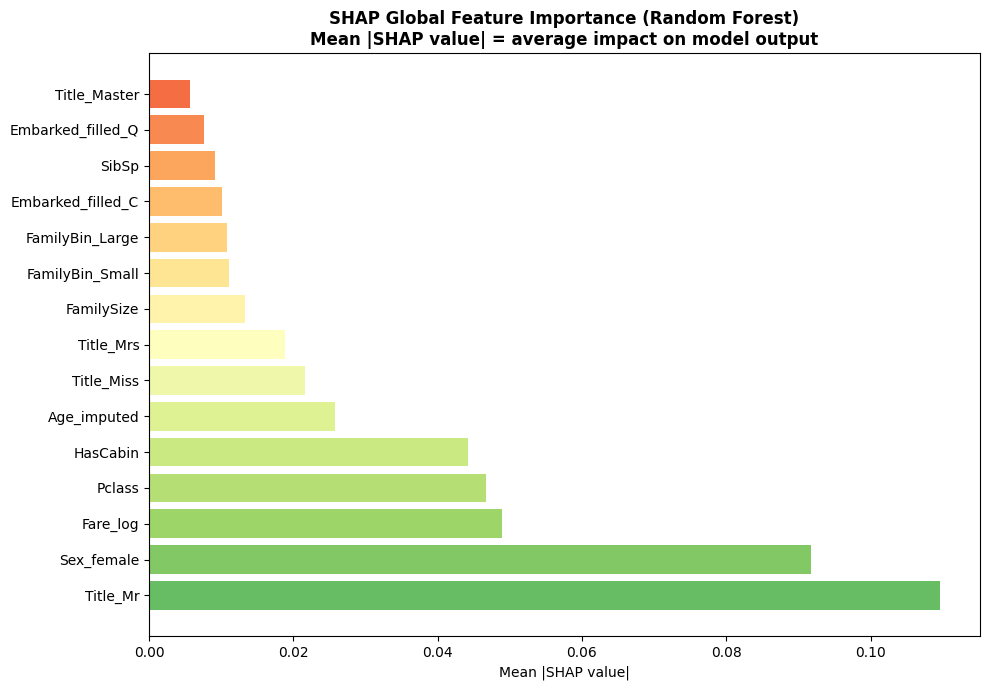

In [70]:


rf_tuned.fit(X_train, y_train)

explainer   = shap.TreeExplainer(rf_tuned)
shap_values = explainer.shap_values(X_test)

# ✅ FIXED handling
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values
    if len(sv.shape) == 3:
        sv = sv[:, :, 1]

print(f"SHAP values shape after fix: {sv.shape}")

# Global importance
mean_abs_shap = np.abs(sv).mean(axis=0)

# ✅ Safety check
assert len(mean_abs_shap) == len(X_test.columns), "Shape mismatch!"

shap_imp = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).head(15)

# Plot
fig, ax = plt.subplots(figsize=(10,7))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(shap_imp)))[::-1]

ax.barh(shap_imp['feature'], shap_imp['mean_abs_shap'], color=colors)
ax.set_title(
    'SHAP Global Feature Importance (Random Forest)\n'
    'Mean |SHAP value| = average impact on model output',
    fontweight='bold'
)
ax.set_xlabel('Mean |SHAP value|')

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'p8_shap_importance.png', bbox_inches='tight')
plt.show()

---
# Phase 9 — MLflow Experiment Tracking

## Why Experiment Tracking?

> Without tracking, ML development is chaotic:
> - 'Which run gave us AUC 0.847? What params did I use?'
> - 'Is today's model better than last week's?'
> - 'What data version was used for that production model?'
>
> **MLflow solves this** by logging every experiment with:
> - Parameters (hyperparameters)
> - Metrics (accuracy, AUC, F1 per epoch/fold)
> - Artifacts (model .pkl, plots, feature importance CSVs)
> - Tags (dataset version, author, git commit)
>
> 🏭 **Industry Note**: MLflow is the de facto standard at most ML teams.
> Every experiment gets a run_id for full reproducibility.
> Production models are promoted from MLflow Model Registry.

In [74]:
# ── 9.1  Setup MLflow experiment ─────────────────────────────────────────────
import mlflow
import mlflow.sklearn

#mlflow.set_tracking_uri(f'file://{MODEL_DIR}/mlruns')
#mlflow.set_tracking_uri(str(MODEL_DIR / "mlruns"))
mlflow.set_tracking_uri(
    f"file://{(MODEL_DIR / 'mlruns').resolve()}"
)
mlflow.set_experiment('Titanic-Survival-Prediction')

print("MLflow experiment set up.")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print()

def log_model_run(name, model, X_tr, y_tr, X_te, y_te, params, is_pipeline=False):
    """Log a complete model run to MLflow."""
    with mlflow.start_run(run_name=name) as run:
        # Log parameters
        mlflow.log_params(params)
        mlflow.log_param('model_type', name)
        mlflow.log_param('train_size', len(X_tr))
        mlflow.log_param('test_size', len(X_te))
        mlflow.log_param('n_features', X_tr.shape[1] if hasattr(X_tr,'shape') else 0)

        # Fit & predict
        model.fit(X_tr, y_tr)
        y_pred  = model.predict(X_te)
        y_proba = model.predict_proba(X_te)[:,1]

        # Compute metrics
        from sklearn.metrics import precision_score, recall_score, average_precision_score
        metrics = {
            'accuracy'         : round(accuracy_score(y_te, y_pred), 4),
            'roc_auc'          : round(roc_auc_score(y_te, y_proba), 4),
            'f1_score'         : round(f1_score(y_te, y_pred), 4),
            'precision'        : round(precision_score(y_te, y_pred), 4),
            'recall'           : round(recall_score(y_te, y_pred), 4),
            'avg_precision'    : round(average_precision_score(y_te, y_proba), 4),
        }
        mlflow.log_metrics(metrics)

        # Log model
        mlflow.sklearn.log_model(model, f'model_{name.lower().replace(" ","_")}')

        # Log confusion matrix as artifact
        cm = confusion_matrix(y_te, y_pred)
        cm_df = pd.DataFrame(cm, index=['Died','Survived'], columns=['Pred_Died','Pred_Surv'])
        cm_path = OUTPUT_DIR / f'cm_{name.lower().replace(" ","_")}.csv'
        cm_df.to_csv(cm_path)
        mlflow.log_artifact(str(cm_path))

        # Tags
        mlflow.set_tag('dataset', 'titanic')
        mlflow.set_tag('phase', 'phase9_tracking')

        print(f"  {name:<22}  AUC={metrics['roc_auc']:.4f}  "
              f"F1={metrics['f1_score']:.4f}  run_id={run.info.run_id[:8]}...")
        return metrics, run.info.run_id

MLflow experiment set up.
Tracking URI: file:///Users/lakshmikalyani/claude-prep-ml/prep/practice/models/mlruns



In [75]:
# ── 9.2  Log all models to MLflow ─────────────────────────────────────────────
print("Logging all models to MLflow...")
print()

mlflow_runs = {}

# Logistic Regression
m, rid = log_model_run('LogisticRegression',
    LogisticRegression(max_iter=1000, random_state=SEED, C=1.0),
    X_train_s, y_train, X_test_s, y_test,
    {'C':1.0, 'penalty':'l2', 'solver':'lbfgs', 'scaling':'StandardScaler'})
mlflow_runs['LogisticRegression'] = {'metrics':m, 'run_id':rid}

# Random Forest  
m, rid = log_model_run('RandomForest', rf_tuned,
    X_train, y_train, X_test, y_test,
    {**rf_gs.best_params_, 'n_estimators':200})
mlflow_runs['RandomForest'] = {'metrics':m, 'run_id':rid}

# XGBoost
m, rid = log_model_run('XGBoost', xgb_tuned,
    X_train, y_train, X_test, y_test,
    {**xgb_fine.best_params_,
     'subsample':random_search.best_params_['subsample'],
     'colsample_bytree':random_search.best_params_['colsample_bytree']})
mlflow_runs['XGBoost'] = {'metrics':m, 'run_id':rid}

# Decision Tree
m, rid = log_model_run('DecisionTree', dt_tuned,
    X_train, y_train, X_test, y_test,
    dt_gs.best_params_)
mlflow_runs['DecisionTree'] = {'metrics':m, 'run_id':rid}

print()
print("All runs logged ✅")
print(f"View MLflow UI: mlflow ui --backend-store-uri {MODEL_DIR}/mlruns")

2026/05/03 23:04:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 23:04:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logging all models to MLflow...



2026/05/03 23:04:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 23:04:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  LogisticRegression      AUC=0.8661  F1=0.7883  run_id=844529c3...
  RandomForest            AUC=0.8510  F1=0.7273  run_id=0972139f...


2026/05/03 23:04:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 23:04:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/03 23:04:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 23:04:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

  XGBoost                 AUC=0.8448  F1=0.7368  run_id=4c3d57f9...
  DecisionTree            AUC=0.8167  F1=0.6615  run_id=934749fc...

All runs logged ✅
View MLflow UI: mlflow ui --backend-store-uri ../practice/models/mlruns


In [76]:
# ── 9.3  Compare all runs programmatically ────────────────────────────────────
client  = mlflow.tracking.MlflowClient()
exp     = client.get_experiment_by_name('Titanic-Survival-Prediction')
runs    = client.search_runs(exp.experiment_id, order_by=['metrics.roc_auc DESC'])

print("MLflow Experiment: Titanic-Survival-Prediction")
print("=" * 70)
print(f"{'Run Name':<22}  {'AUC':>6}  {'Accuracy':>8}  {'F1':>6}  {'Precision':>9}  {'Run ID':>10}")
print("-" * 70)
for run in runs[:8]:
    m = run.data.metrics
    p = run.data.params
    name = run.data.tags.get('mlflow.runName','?')
    print(f"{name:<22}  {m.get('roc_auc',0):>6.4f}  "
          f"{m.get('accuracy',0):>8.4f}  {m.get('f1_score',0):>6.4f}  "
          f"{m.get('precision',0):>9.4f}  {run.info.run_id[:8]:>10}")

print()
print("Best model:", runs[0].data.tags.get('mlflow.runName','?'),
      f"→ AUC = {runs[0].data.metrics.get('roc_auc',0):.4f}")

MLflow Experiment: Titanic-Survival-Prediction
Run Name                   AUC  Accuracy      F1  Precision      Run ID
----------------------------------------------------------------------
LogisticRegression      0.8661    0.8380  0.7883     0.7941    844529c3
RandomForest            0.8510    0.7989  0.7273     0.7619    0972139f
XGBoost                 0.8448    0.8045  0.7368     0.7656    4c3d57f9
DecisionTree            0.8167    0.7542  0.6615     0.7049    934749fc

Best model: LogisticRegression → AUC = 0.8661


In [77]:
# ── Final Model Card ─────────────────────────────────────────────────────────
best_model_name = max(final_results, key=lambda k: final_results[k]['AUC']
                       if k != 'model' else 0)
best = {k:v for k,v in final_results[best_model_name].items() if k != 'model'}
y_pred_best   = best.pop('y_pred', None)
y_proba_best  = best.pop('y_proba', None)

print("╔══════════════════════════════════════════════════════════════╗")
print("║              TITANIC MODEL CARD — FINAL RESULTS             ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  Best Model   : {best_model_name:<44}║")
print(f"║  Accuracy     : {best['Accuracy']:.4f}                                      ║")
print(f"║  AUC-ROC      : {best['AUC']:.4f}                                      ║")
print(f"║  F1-Score     : {best['F1']:.4f}                                      ║")
print(f"║  Precision    : {best['Precision']:.4f}                                      ║")
print(f"║  Recall       : {best['Recall']:.4f}                                      ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  Pipeline saved: models/titanic_xgboost_pipeline.pkl        ║")
print("║  MLflow runs  : models/mlruns/                               ║")
print("║  SHAP plots   : outputs/p8_shap_*.png                        ║")
print("╚══════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════╗
║              TITANIC MODEL CARD — FINAL RESULTS             ║
╠══════════════════════════════════════════════════════════════╣
║  Best Model   : Logistic Regression                         ║
║  Accuracy     : 0.8380                                      ║
║  AUC-ROC      : 0.8661                                      ║
║  F1-Score     : 0.7883                                      ║
║  Precision    : 0.7941                                      ║
║  Recall       : 0.7826                                      ║
╠══════════════════════════════════════════════════════════════╣
║  Pipeline saved: models/titanic_xgboost_pipeline.pkl        ║
║  MLflow runs  : models/mlruns/                               ║
║  SHAP plots   : outputs/p8_shap_*.png                        ║
╚══════════════════════════════════════════════════════════════╝
